# Sequences quality/Filtering

## Imports

In [139]:
from Bio.SeqUtils.IsoelectricPoint import IsoelectricPoint as IEP
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from Bio.SeqUtils.lcc import lcc_simp
import re

import os
import seaborn as sns

from scipy.stats import ks_2samp, mannwhitneyu, entropy
from pathlib import Path
import random
import glob

## Files to Aggrescan

In [140]:
path_ProtGPT = './files/generated_datasets/protGPT2_generated_sequences-17833.csv'
path_CVAE = 'files/generated_datasets/CVAE_generated_sequences-18620.csv'
path_diff = 'files/generated_datasets/Diff_generated_sequences-16334.csv'

df_protgpt = pd.read_csv(path_ProtGPT)
df_cvae = pd.read_csv(path_CVAE)
df_diff = pd.read_csv(path_diff)

In [141]:
print(len(df_protgpt))
print(len(df_cvae))
print(len(df_diff))

17833
18620
16334


In [142]:
if "id" not in df_protgpt.columns:
    df_protgpt.insert(
        0,
        "id",
        [f"ProtGPT2_{i+1}" for i in range(len(df_protgpt))]
    )

if "id" not in df_cvae.columns:
    df_cvae.insert(
        0,
        "id",
        [f"CVAE_{i+1}" for i in range(len(df_cvae))]
    )

if "id" not in df_diff.columns:
    df_diff.insert(
        0,
        "id",
        [f"DIFF_{i+1}" for i in range(len(df_diff))]
    )

In [143]:
df_protgpt.head()

,id,sequence,length
0,ProtGPT2_1,GTVQLRDGGNVYSGTAYTGDQTNQY,25
1,ProtGPT2_2,GEVNQNYQINNNNNTNNSA,19
2,ProtGPT2_3,GSVQVGDA,8
3,ProtGPT2_4,SSVAVQGDQTNTFN,14
4,ProtGPT2_5,GSVHIHQNISGDISGG,16


In [144]:
df_cvae.head()

,id,sequence,length
0,CVAE_1,PITVNF,6
1,CVAE_2,VNSLQAGV,8
2,CVAE_3,STVKAVQYGDM,11
3,CVAE_4,PINLYIALN,9
4,CVAE_5,VQSTGGKGTA,10


In [145]:
df_diff.head()

,id,sequence,length
0,DIFF_1,PNQDE,5
1,DIFF_2,DCPVASIYEHSIE,13
2,DIFF_3,NKQTVQRWTLPHVG,14
3,DIFF_4,EYNEVEYDYTYW,12
4,DIFF_5,LQDHALHEPATTIP,14


### Invalid sequences

In [146]:
AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"

In [147]:
def find_invalid_sequences(df, seq_col="sequence"):
    valid = set(AMINO_ACIDS)
    invalid_rows = []

    for i, seq in df[seq_col].items():
        bad_chars = set(seq) - valid

        if len(bad_chars) > 0:
            invalid_rows.append({
                "index": i,
                "sequence": seq,
                "invalid_chars": "".join(sorted(bad_chars))
            })

    return pd.DataFrame(invalid_rows)

In [148]:
bad_df_prot = find_invalid_sequences(df_protgpt)

print(bad_df_prot.head())
print("Invalid sequences:", len(bad_df_prot))

Empty DataFrame
Columns: []
Index: []
Invalid sequences: 0


In [149]:
bad_df_cvae = find_invalid_sequences(df_cvae)

print(bad_df_cvae.head())
print("Invalid sequences:", len(bad_df_cvae))

Empty DataFrame
Columns: []
Index: []
Invalid sequences: 0


In [150]:
bad_df_diff = find_invalid_sequences(df_diff)

print(bad_df_diff.head())
print("Invalid sequences:", len(bad_df_diff))

Empty DataFrame
Columns: []
Index: []
Invalid sequences: 0


In [151]:
def write_fasta(df, filename, seq_col="sequence", id_col="id"):
    with open(filename, "w") as f:
        for i, row in df.iterrows():
            sid = row.get(id_col, f"gen_{i}")
            seq = row[seq_col]
            f.write(f">{sid}\n{seq}\n")

In [152]:
write_fasta(df_protgpt, './files/generated_datasets/Aggrescan_protGPT2_generated_sequences-17833.fasta')
write_fasta(df_cvae, './files/generated_datasets/Aggrescan_CVAE_generated_sequences-18620.fasta')
write_fasta(df_diff, './files/generated_datasets/Aggrescan_DIFF_generated_sequences-16334.fasta')

## Aggrescan features

In [153]:
def aggrescan_features_extraction(path):
    agg_data = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if not (line[0].isdigit() or line[0] == '-'):
                continue

            cols = line.split()
            if len(cols) < 13:
                continue

            agg_data.append({
                "id": cols[1].replace(">", ""),
                "a3vSA": float(cols[0]),
                "AAT": float(cols[5]),
                "Na4vSS": float(cols[7]),
                "THSA": float(cols[9]),
                "nHS": int(cols[11]),
                "TA": float(cols[12]),
            })

    df_agg = pd.DataFrame(agg_data)
    return df_agg

In [154]:
agg_file_protgpt = "files/generated_datasets/protGPT2_generated_sequences-17833.out"
agg_file_cvae = "files/generated_datasets/CVAE_generated_sequences-18620.out"
agg_file_diff = "files/generated_datasets/Diff_generated_sequences-16334.out"

df_agg_protgpt = aggrescan_features_extraction(agg_file_protgpt)
df_agg_cvae = aggrescan_features_extraction(agg_file_cvae)
df_agg_diff = aggrescan_features_extraction(agg_file_diff)

In [155]:
def merge_with_agg(df_main, df_agg):
    df_agg = df_agg.drop(columns=[c for c in ["sequence", "length"] if c in df_agg.columns], errors="ignore")

    df = df_main.merge(df_agg, on="id", how="left")

    left_cols = ["id", "sequence", "length"]
    other_cols = [c for c in df.columns if c not in left_cols]

    return df[left_cols + other_cols]

In [156]:
df_protgpt = merge_with_agg(df_protgpt, df_agg_protgpt)
df_cvae = merge_with_agg(df_cvae, df_agg_cvae)
df_diff = merge_with_agg(df_diff, df_agg_diff)

In [157]:
df_protgpt.head()

,id,sequence,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA
0,ProtGPT2_1,GTVQLRDGGNVYSGTAYTGDQTNQY,25,-0.272,1.319,-0.326,1.0,1,-7.200900
1,ProtGPT2_2,GEVNQNYQINNNNNTNNSA,19,-0.634,0.000,-0.688,0.0,0,-11.986001
2,ProtGPT2_3,GSVQVGDA,8,-0.160,0.491,-0.204,0.0,0,-1.096800
3,ProtGPT2_4,SSVAVQGDQTNTFN,14,-0.245,1.175,-0.317,0.0,0,-3.907000
4,ProtGPT2_5,GSVHIHQNISGDISGG,16,-0.150,0.857,-0.171,0.0,0,-2.177100


In [158]:
df_cvae.head()

,id,sequence,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA
0,CVAE_1,PITVNF,6,0.562,1.747,0.318,1.747,1,1.7963
1,CVAE_2,VNSLQAGV,8,0.146,0.304,-0.099,0.000,0,-0.4977
2,CVAE_3,STVKAVQYGDM,11,0.021,1.046,-0.059,1.046,1,-0.1703
3,CVAE_4,PINLYIALN,9,0.510,4.331,0.462,4.331,1,4.2477
4,CVAE_5,VQSTGGKGTA,10,-0.282,0.000,-0.447,0.000,0,-3.8418


In [159]:
df_diff.head()

,id,sequence,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA
0,DIFF_1,PNQDE,5,-1.223,0.000,-1.300,0.000,0,-5.1009
1,DIFF_2,DCPVASIYEHSIE,13,0.027,2.239,0.015,2.239,1,0.7924
2,DIFF_3,NKQTVQRWTLPHVG,14,-0.182,0.630,-0.224,0.000,0,-2.2060
3,DIFF_4,EYNEVEYDYTYW,12,-0.022,1.646,-0.143,0.000,0,-1.2458
4,DIFF_5,LQDHALHEPATTIP,14,-0.216,0.531,-0.349,0.000,0,-4.1937


## Rest features extraction

In [160]:
hydro_scale = {
    'A': 1.8, 'C': 2.5, 'D': -3.5, 'E': -3.5, 'F': 2.8, 'G': -0.4, 'H': -3.2, 'I': 4.5,
    'K': -3.9, 'L': 3.8, 'M': 1.9, 'N': -3.5, 'P': -1.6, 'Q': -3.5, 'R': -4.5, 'S': -0.8,
    'T': -0.7, 'V': 4.2, 'W': -0.9, 'Y': -1.3
}

beta_prop = {
    'A': 0.83, 'C': 1.19, 'D': 0.54, 'E': 0.37, 'F': 1.38, 'G': 0.75, 'H': 0.87, 'I': 1.60,
    'K': 0.74, 'L': 1.30, 'M': 1.05, 'N': 0.89, 'P': 0.55, 'Q': 1.10, 'R': 0.93, 'S': 0.75,
    'T': 1.19, 'V': 1.70, 'W': 1.37, 'Y': 1.47
}

valid_aas = set("ACDEFGHIKLMNPQRSTVWY")

def clean_sequence(seq):
    seq = seq.upper().strip()
    seq = "".join([a for a in seq if a in valid_aas])
    return seq


def seq_entropy(seq):
    from collections import Counter
    c = Counter(seq)
    L = len(seq)
    return -sum((v / L) * np.log2(v / L) for v in c.values())


def net_charge(seq):
    return seq.count('K') + seq.count('R') - seq.count('D') - seq.count('E') + 0.1 * seq.count('H')

def aa_fraction(seq, group):
    aa_groups = {
        "polar": "NQSTY",
        "nonpolar": "ACFGILMPVW",
        "acidic": "DE",
        "basic": "HKR",
    }
    return sum(seq.count(a) for a in aa_groups[group]) / len(seq) if len(seq) > 0 else 0


def compute_features(seq):
    seq = clean_sequence(seq)
    seq = seq.upper().strip()
    L = len(seq)

    pa = ProteinAnalysis(seq)
    iep = IEP(seq).pi()


    return {
        "length": L,
        "entropy": seq_entropy(seq),
        "hydrophobicity": sum(hydro_scale[a] for a in seq) / L,
        "net_charge": net_charge(seq),
        "beta_propensity": sum(beta_prop[a] for a in seq) / L,
        "aromatic_fraction": sum(seq.count(a) for a in "FYW") / L,
        "proline_fraction": seq.count("P") / L,
        "pI": iep,
        "gravy": pa.gravy(),
        "instability_index": pa.instability_index(),
        "polar_fraction": aa_fraction(seq, "polar"),
        "nonpolar_fraction": aa_fraction(seq, "nonpolar"),
        "acidic_fraction": aa_fraction(seq, "acidic"),
        "basic_fraction": aa_fraction(seq, "basic"),
    }

In [161]:
def add_features(df, seq_col="sequence"):
    feats = df[seq_col].apply(compute_features)
    return pd.concat([df.reset_index(drop=True), pd.DataFrame(list(feats))], axis=1)

In [162]:
df_protgpt = add_features(df_protgpt)
df_cvae = add_features(df_cvae)
df_diff = add_features(df_diff)

In [163]:
df_protgpt.head()

,id,sequence,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,length,entropy,hydrophobicity,net_charge,beta_propensity,aromatic_fraction,proline_fraction,pI,gravy,instability_index,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction
0,ProtGPT2_1,GTVQLRDGGNVYSGTAYTGDQTNQY,25,-0.272,1.319,-0.326,1.0,1,-7.200900,25,3.239080,-0.980000,-1.0,1.051600,0.120000,0.0,4.207813,-0.980000,-9.800000,0.520000,0.360000,0.080000,0.040
1,ProtGPT2_2,GEVNQNYQINNNNNTNNSA,19,-0.634,0.000,-0.688,0.0,0,-11.986001,19,2.641121,-1.826316,-1.0,0.993158,0.052632,0.0,4.050028,-1.826316,-10.842105,0.736842,0.210526,0.052632,0.000
2,ProtGPT2_3,GSVQVGDA,8,-0.160,0.491,-0.204,0.0,0,-1.096800,8,2.500000,0.200000,-1.0,1.015000,0.000000,0.0,4.050028,0.200000,-11.287500,0.250000,0.625000,0.125000,0.000
3,ProtGPT2_4,SSVAVQGDQTNTFN,14,-0.245,1.175,-0.317,0.0,0,-3.907000,14,3.093069,-0.564286,-1.0,1.054286,0.071429,0.0,4.050028,-0.564286,15.057143,0.571429,0.357143,0.071429,0.000
4,ProtGPT2_5,GSVHIHQNISGDISGG,16,-0.150,0.857,-0.171,0.0,0,-2.177100,16,2.780639,-0.200000,-0.8,1.001250,0.000000,0.0,5.968799,-0.200000,79.725000,0.312500,0.500000,0.062500,0.125


In [164]:
df_cvae.head()

,id,sequence,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,length,entropy,hydrophobicity,net_charge,beta_propensity,aromatic_fraction,proline_fraction,pI,gravy,instability_index,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction
0,CVAE_1,PITVNF,6,0.562,1.747,0.318,1.747,1,1.7963,6,2.584963,0.950000,0.0,1.218333,0.166667,0.166667,5.954987,0.950000,-16.716667,0.333333,0.666667,0.000000,0.000000
1,CVAE_2,VNSLQAGV,8,0.146,0.304,-0.099,0.000,0,-0.4977,8,2.750000,0.725000,0.0,1.127500,0.000000,0.000000,5.494989,0.725000,49.500000,0.375000,0.625000,0.000000,0.000000
2,CVAE_3,STVKAVQYGDM,11,0.021,1.046,-0.059,1.046,1,-0.1703,11,3.277613,-0.181818,0.0,1.074545,0.090909,0.000000,5.552567,-0.181818,-8.100000,0.363636,0.454545,0.090909,0.090909
3,CVAE_4,PINLYIALN,9,0.510,4.331,0.462,4.331,1,4.2477,9,2.503258,0.944444,0.0,1.158889,0.111111,0.111111,5.950042,0.944444,8.888889,0.333333,0.666667,0.000000,0.000000
4,CVAE_5,VQSTGGKGTA,10,-0.282,0.000,-0.447,0.000,0,-3.8418,10,2.646439,-0.480000,1.0,0.975000,0.000000,0.000000,8.720010,-0.480000,31.320000,0.400000,0.500000,0.000000,0.100000


In [165]:
df_diff.head()

,id,sequence,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,length,entropy,hydrophobicity,net_charge,beta_propensity,aromatic_fraction,proline_fraction,pI,gravy,instability_index,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction
0,DIFF_1,PNQDE,5,-1.223,0.000,-1.300,0.000,0,-5.1009,5,2.321928,-3.120000,-2.0,0.690000,0.000000,0.200000,4.085382,-3.120000,31.440000,0.400000,0.200000,0.400000,0.000000
1,DIFF_2,DCPVASIYEHSIE,13,0.027,2.239,0.015,2.239,1,0.7924,13,3.238901,-0.053846,-2.9,0.968462,0.076923,0.076923,4.414196,-0.053846,61.061538,0.230769,0.461538,0.230769,0.076923
2,DIFF_3,NKQTVQRWTLPHVG,14,-0.182,0.630,-0.224,0.000,0,-2.2060,14,3.378783,-1.014286,2.1,1.098571,0.071429,0.071429,11.000837,-1.014286,80.957143,0.357143,0.428571,0.000000,0.214286
3,DIFF_4,EYNEVEYDYTYW,12,-0.022,1.646,-0.143,0.000,0,-1.2458,12,2.522055,-1.675000,-4.0,1.056667,0.416667,0.000000,4.050028,-1.675000,13.183333,0.500000,0.166667,0.333333,0.000000
4,DIFF_5,LQDHALHEPATTIP,14,-0.216,0.531,-0.349,0.000,0,-4.1937,14,3.093069,-0.414286,-1.8,0.935000,0.000000,0.142857,5.152136,-0.414286,71.785714,0.214286,0.500000,0.142857,0.142857


In [166]:
df_protgpt.describe()

,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,length,entropy,hydrophobicity,net_charge,beta_propensity,aromatic_fraction,proline_fraction,pI,gravy,instability_index,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction
count,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000,17833.000000
mean,21.583020,-0.168443,1.739794,-0.224040,0.949016,0.407279,-4.733006,21.583020,3.072355,-0.469426,-0.583368,1.032379,0.078355,0.007913,5.831606,-0.469426,14.587298,0.390190,0.464393,0.067830,0.077587
std,13.386399,0.254143,1.766680,0.225993,1.732674,0.578560,5.753339,13.386399,0.382840,0.671793,1.323289,0.072069,0.080193,0.022023,1.542232,0.671793,25.831109,0.147480,0.133064,0.056122,0.064969
min,5.000000,-1.081000,0.000000,-1.107000,0.000000,0.000000,-104.516197,5.000000,1.251629,-2.777778,-17.800000,0.690000,0.000000,0.000000,4.050028,-2.777778,-63.411111,0.000000,0.000000,0.000000,0.000000
25%,14.000000,-0.324000,0.500000,-0.361000,0.000000,0.000000,-7.023201,14.000000,2.852217,-0.900000,-1.000000,0.988333,0.000000,0.000000,4.702767,-0.900000,-3.113043,0.285714,0.375000,0.000000,0.000000
50%,19.000000,-0.206000,1.271000,-0.248000,0.000000,0.000000,-3.987500,19.000000,3.135822,-0.533333,0.000000,1.025385,0.062500,0.000000,5.524318,-0.533333,11.902439,0.384615,0.454545,0.066667,0.071429
75%,26.000000,-0.065000,2.426000,-0.121000,1.533000,1.000000,-1.345600,26.000000,3.346439,-0.107407,0.100000,1.066667,0.111111,0.000000,6.609431,-0.107407,29.325000,0.485714,0.545455,0.105263,0.120000
max,178.000000,1.526000,32.682000,1.207000,32.682000,5.000000,18.399298,178.000000,3.992709,3.500000,5.200000,1.514000,0.600000,0.222222,11.999968,3.500000,156.227273,1.000000,1.000000,0.375000,0.444444


In [167]:
df_cvae.describe()

,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,length,entropy,hydrophobicity,net_charge,beta_propensity,aromatic_fraction,proline_fraction,pI,gravy,instability_index,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction
count,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000,18620.000000
mean,14.343555,-0.003343,2.291776,-0.092870,1.772187,0.512567,-0.902411,14.343555,2.978468,-0.045783,0.105338,1.035560,0.052127,0.041662,6.576836,-0.045783,23.406131,0.309257,0.529110,0.065310,0.096323
std,6.676135,0.371547,2.888769,0.336215,2.866550,0.621683,4.485766,6.676135,0.425162,0.940445,1.312482,0.124900,0.059662,0.069780,2.031714,0.940445,31.928916,0.165500,0.150067,0.068296,0.092459
min,5.000000,-1.008000,0.000000,-1.030000,0.000000,0.000000,-25.538597,5.000000,0.650022,-2.962500,-10.900000,0.491667,0.000000,0.000000,4.050028,-2.962500,-73.000000,0.000000,0.000000,0.000000,0.000000
25%,10.000000,-0.265000,0.336000,-0.328000,0.000000,0.000000,-3.661625,10.000000,2.725481,-0.700000,-0.900000,0.952500,0.000000,0.000000,5.240009,-0.700000,0.071667,0.200000,0.428571,0.000000,0.000000
50%,13.000000,-0.050000,1.382000,-0.130000,0.000000,0.000000,-1.084150,13.000000,3.039149,-0.159630,0.000000,1.024286,0.047619,0.000000,5.950042,-0.159630,19.770000,0.300000,0.521739,0.058824,0.083333
75%,18.000000,0.204000,3.226000,0.102000,2.822000,1.000000,1.550075,18.000000,3.292770,0.488889,1.000000,1.105000,0.086957,0.071429,8.561547,0.488889,42.628143,0.411765,0.625000,0.111111,0.153846
max,50.000000,1.694000,75.434000,1.478000,75.434000,5.000000,73.765114,50.000000,3.970176,4.320000,12.000000,1.660000,0.444444,0.660000,11.999968,4.320000,197.600000,1.000000,1.000000,0.500000,0.666667


In [168]:
df_diff.describe()

,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,length,entropy,hydrophobicity,net_charge,beta_propensity,aromatic_fraction,proline_fraction,pI,gravy,instability_index,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction
count,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000,16334.000000
mean,13.851414,-0.057607,2.258255,-0.143424,1.675072,0.473491,-1.228521,13.851414,3.107080,-0.658920,-0.446755,1.023352,0.155041,0.047443,6.230925,-0.658920,41.317784,0.267009,0.470295,0.122373,0.140324
std,4.564526,0.345694,2.368910,0.328426,2.412939,0.565006,4.082084,4.564526,0.414587,0.838238,1.702893,0.108603,0.104849,0.061611,1.956516,0.838238,36.126303,0.127970,0.143944,0.095544,0.099770
min,5.000000,-1.523000,0.000000,-1.520000,0.000000,0.000000,-17.266502,5.000000,0.970951,-3.683333,-8.900000,0.573333,0.000000,0.000000,4.050028,-3.683333,-67.200000,0.000000,0.000000,0.000000,0.000000
25%,12.000000,-0.285000,0.344000,-0.358750,0.000000,0.000000,-3.877950,12.000000,2.921928,-1.218750,-1.800000,0.952163,0.071429,0.000000,4.491156,-1.218750,15.545250,0.181818,0.375000,0.062500,0.066667
50%,15.000000,-0.062500,1.581000,-0.143000,0.000000,0.000000,-1.266800,15.000000,3.189898,-0.676607,0.000000,1.023258,0.142857,0.000000,5.834261,-0.676607,37.815000,0.266667,0.466667,0.117647,0.133333
75%,16.000000,0.167000,3.462750,0.077000,2.990750,1.000000,1.386575,16.000000,3.378783,-0.128571,1.000000,1.094000,0.214286,0.071429,7.967809,-0.128571,63.521667,0.350000,0.571429,0.181818,0.200000
max,50.000000,1.493000,20.517000,1.076000,20.517000,4.000000,19.177597,50.000000,4.061482,3.360000,7.000000,1.522000,0.714286,0.666667,11.999968,3.360000,248.342857,1.000000,1.000000,0.666667,0.800000


## Reference dataset

In [169]:
ref_path = "files/df_ml_good_with_features.csv"
df_ref = pd.read_csv(ref_path)
print(len(df_ref))

df_ref = df_ref[df_ref['class'] == 1]
print(len(df_ref))

1934
1006


## Low-complexity filtering (SEG/LCC)

In [170]:
def low_complexity_score(seq):
    return lcc_simp(seq)

In [171]:
df_ref["lcc"] = df_ref["sequence"].apply(low_complexity_score)

In [172]:
df_protgpt["lcc"] = df_protgpt["sequence"].apply(low_complexity_score)
df_cvae["lcc"] = df_cvae["sequence"].apply(low_complexity_score)
df_diff["lcc"] = df_diff["sequence"].apply(low_complexity_score)

In [173]:
print("REFERENCE")
print(df_ref["lcc"].describe())

print("\nCVAE")
print(df_cvae["lcc"].describe())

print("\nProtGPT")
print(df_protgpt["lcc"].describe())

print("\nDiffusion model")
print(df_diff["lcc"].describe())

REFERENCE
count    1006.000000
mean        0.360372
std         0.163138
min         0.000000
25%         0.250000
50%         0.398289
75%         0.477496
max         0.730119
Name: lcc, dtype: float64

CVAE
count    18620.000000
mean         0.359897
std          0.147149
min          0.000000
25%          0.266118
50%          0.380832
75%          0.464386
max          0.859770
Name: lcc, dtype: float64

ProtGPT
count    17833.000000
mean         0.423604
std          0.127432
min          0.000000
25%          0.358048
50%          0.437500
75%          0.510480
max          0.748181
Name: lcc, dtype: float64

Diffusion model
count    16334.000000
mean         0.285697
std          0.153232
min          0.000000
25%          0.187500
50%          0.271954
75%          0.390689
max          0.910401
Name: lcc, dtype: float64


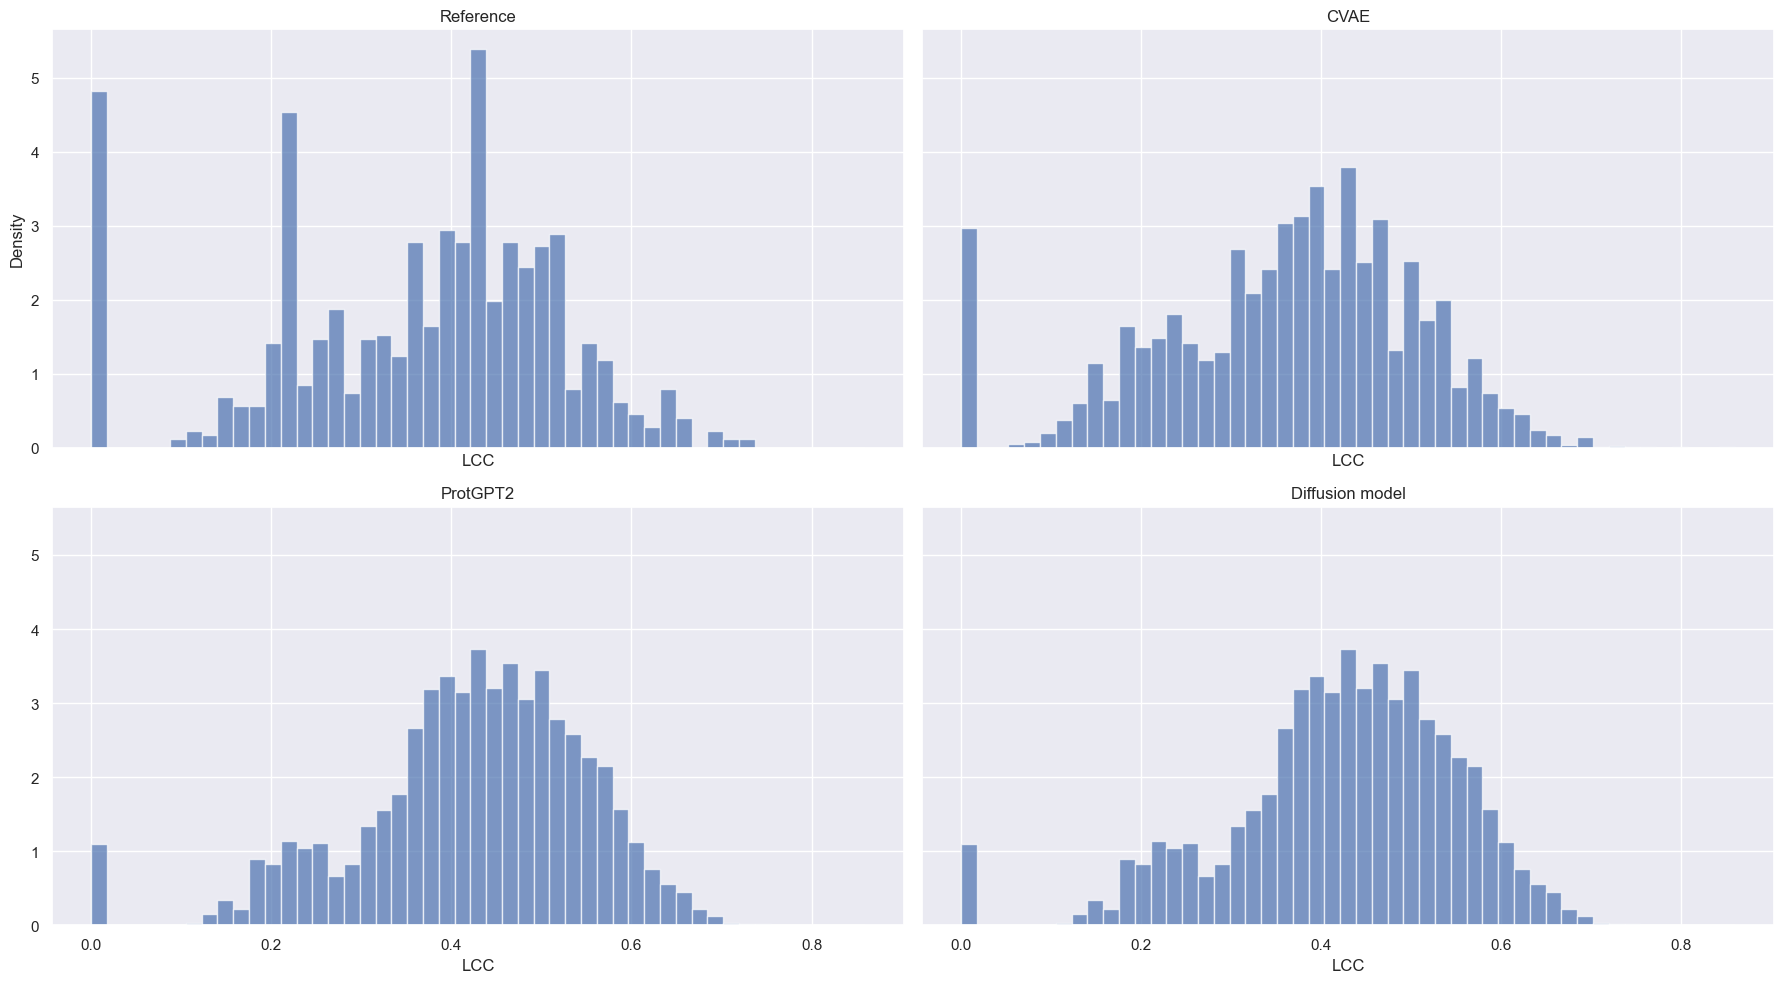

In [174]:
bins = np.linspace(
    min(
        df_ref["lcc"].min(),
        df_cvae["lcc"].min(),
        df_protgpt["lcc"].min()
    ),
    max(
        df_ref["lcc"].max(),
        df_cvae["lcc"].max(),
        df_protgpt["lcc"].max()
    ),
    50
)

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True, sharey=True)

# REF
axes[0][0].hist(
    df_ref["lcc"],
    bins=bins,
    density=True,
    alpha=0.7
)

axes[0][0].set_title("Reference")
axes[0][0].set_xlabel("LCC")
axes[0][0].set_ylabel("Density")

# CVAE
axes[0][1].hist(
    df_cvae["lcc"],
    bins=bins,
    density=True,
    alpha=0.7
)

axes[0][1].set_title("CVAE")
axes[0][1].set_xlabel("LCC")

# PROTGPT
axes[1][0].hist(
    df_protgpt["lcc"],
    bins=bins,
    density=True,
    alpha=0.7
)

axes[1][0].set_title("ProtGPT2")
axes[1][0].set_xlabel("LCC")

# DIFFUSION
axes[1][1].hist(
    df_protgpt["lcc"],
    bins=bins,
    density=True,
    alpha=0.7
)

axes[1][1].set_title("Diffusion model")
axes[1][1].set_xlabel("LCC")


plt.tight_layout()
plt.savefig(
    "./files/plots/lcc_distribution_comparison.svg",
    format="svg",
    bbox_inches="tight"
)
plt.show()

In [175]:
#cutoff = df_ref["lcc"].quantile(0.005)

In [176]:
#df_cvae = df_cvae[
#    df_cvae["lcc"] > cutoff
#].copy()

#df_protgpt = df_protgpt[
#    df_protgpt["lcc"] > cutoff
#].copy()

In [177]:
print(len(df_cvae))
print(len(df_protgpt))
print(len(df_diff))

18620
17833
16334


## Repetition filtering

In [178]:
def has_bad_repeats(seq):

    # >=4 same AA in a row
    if re.search(r"(.)\1{3,}", seq):
        return True

    # repeating 2-AA motif - token loop
    if re.search(r"(.{2})\1{3,}", seq):
        return True

    return False

In [179]:
print("CVAE bad repeats:", df_cvae["sequence"].apply(has_bad_repeats).sum())
print("GPT bad repeats:", df_protgpt["sequence"].apply(has_bad_repeats).sum())
print("Diffusion bad repeats:", df_diff["sequence"].apply(has_bad_repeats).sum())

CVAE bad repeats: 316
GPT bad repeats: 1219
Diffusion bad repeats: 53


In [180]:
df_cvae = df_cvae[
    ~df_cvae["sequence"].apply(has_bad_repeats)
].copy()

df_protgpt = df_protgpt[
    ~df_protgpt["sequence"].apply(has_bad_repeats)
].copy()

df_diff = df_diff[
    ~df_diff["sequence"].apply(has_bad_repeats)
].copy()

In [181]:
print(len(df_cvae))
print(len(df_protgpt))
print(len(df_diff))

18304
16614
16281


## Scoring against reference amyloids

In [182]:
def score_vs_amyloids(df_gen_feat, df_amy_ref_feat, feature_cols, z_cutoff=2.25):
    df_scored = df_gen_feat.copy()

    df_scored = df_scored.drop(columns=[c for c in df_scored.columns if c.endswith("_z")], errors="ignore")

    z_abs_vals = []

    for c in feature_cols:
        mu = df_amy_ref_feat[c].mean()
        sd = df_amy_ref_feat[c].std()

        if sd == 0 or np.isnan(sd):
            z = (df_scored[c] - mu) * 0.0
        else:
            z = (df_scored[c] - mu) / sd

        df_scored[c + "_z"] = z
        z_abs_vals.append(z.abs())

    z_abs_stack = np.vstack([z.values for z in z_abs_vals])

    score = z_abs_stack.mean(axis=0)
    length_penalty = np.log1p(df_scored["length"].iloc[:, 0].values)
    df_scored["amyloid_likeness_score_norm"] = score / length_penalty
    df_scored["flag_outlier"] = (z_abs_stack > z_cutoff).any(axis=0)

    return df_scored

In [183]:
features = ['beta_propensity', 'proline_fraction', 'AAT', 'net_charge', 'TA', 'polar_fraction', 'a3vSA']

df_gen_scored_protgpt = score_vs_amyloids(df_protgpt, df_ref, features)
df_gen_scored_cvae = score_vs_amyloids(df_cvae, df_ref, features)
df_gen_scored_diff = score_vs_amyloids(df_diff, df_ref, features)

In [184]:
df_good_protgpt = df_gen_scored_protgpt[
    (df_gen_scored_protgpt["flag_outlier"] == False) &
    (df_gen_scored_protgpt["amyloid_likeness_score_norm"] < 1.0)
].copy()

df_good_protgpt['id'] = df_good_protgpt['id'].str.replace(r'\s+_', '_', regex=True)

print("Keept:", len(df_good_protgpt), "from", len(df_gen_scored_protgpt))

df_protgpt = df_good_protgpt.copy()

Keept: 13841 from 16614


In [185]:
df_good_cvae = df_gen_scored_cvae[
    (df_gen_scored_cvae["flag_outlier"] == False) &
    (df_gen_scored_cvae["amyloid_likeness_score_norm"] < 1.5)
].copy()

df_good_cvae['id'] = df_good_cvae['id'].str.replace(r'\s+_', '_', regex=True)

print("Keept:", len(df_good_cvae), "from", len(df_gen_scored_cvae))

df_cvae = df_good_cvae.copy()

Keept: 10967 from 18304


In [186]:
df_good_diff = df_gen_scored_diff[
    (df_gen_scored_diff["flag_outlier"] == False) &
    (df_gen_scored_diff["amyloid_likeness_score_norm"] < 1.5)
].copy()

df_good_diff['id'] = df_good_diff['id'].str.replace(r'\s+_', '_', regex=True)

print("Keept:", len(df_good_diff), "from", len(df_gen_scored_diff))

df_diff = df_good_diff.copy()

Keept: 8295 from 16281


In [187]:
def plot_pca_tsne(dfs_dict, feature_cols, color_col=None, perplexity=30, random_state=42, figsize=(14, 6)):
    prepared = []

    for label, df in dfs_dict.items():
        df_ = df.copy()

        df_ = df_[feature_cols]

        df_ = df_.groupby(level=0, axis=1).mean()

        df_["source"] = label

        if color_col and color_col in df.columns:
            df_[color_col] = df[color_col].values

        prepared.append(df_)

    df_all = pd.concat(prepared, ignore_index=True)

    df_all = df_all.dropna(subset=feature_cols)

    X = df_all[feature_cols].values
    y = df_all["source"].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # tSNE
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_state)
    X_tsne = tsne.fit_transform(X_scaled)

    # plot
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # PCA
    for label in np.unique(y):
        idx = y == label
        axes[0].scatter(
            X_pca[idx, 0],
            X_pca[idx, 1],
            label=label,
            alpha=0.6
        )

    axes[0].set_title("PCA")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[0].legend()

    # t-SEN
    for label in np.unique(y):
        idx = y == label
        axes[1].scatter(
            X_tsne[idx, 0],
            X_tsne[idx, 1],
            label=label,
            alpha=0.4
        )

    axes[1].set_title("t-SNE")
    axes[1].set_xlabel("TSNE1")
    axes[1].set_ylabel("TSNE2")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("./files/plots/generated_vs_ref_pca_tsne.svg", format="svg", bbox_inches="tight")
    plt.show()

C:\Users\marts\AppData\Local\Temp\ipykernel_32408\2109436172.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_ = df_.groupby(level=0, axis=1).mean()
C:\Users\marts\AppData\Local\Temp\ipykernel_32408\2109436172.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_ = df_.groupby(level=0, axis=1).mean()
C:\Users\marts\AppData\Local\Temp\ipykernel_32408\2109436172.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_ = df_.groupby(level=0, axis=1).mean()
C:\Users\marts\AppData\Local\Temp\ipykernel_32408\2109436172.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_ = df_.groupby(level=0, axis=1).mean()


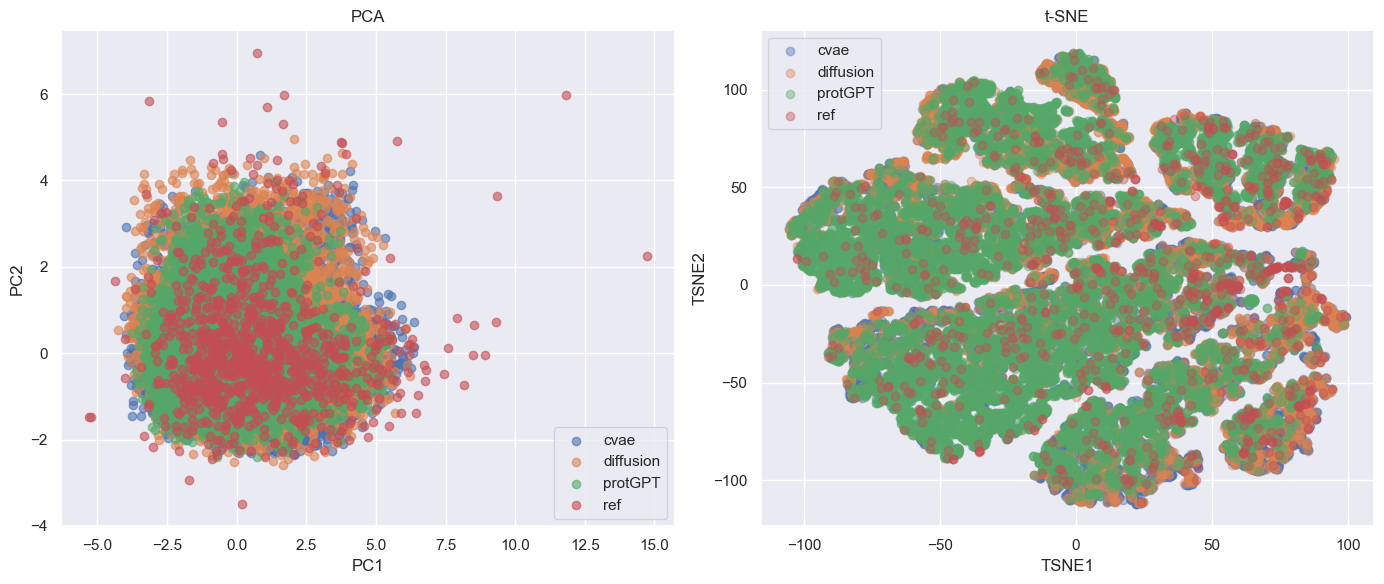

In [188]:
dfs = {
    "ref": df_ref,
    "cvae": df_cvae,
    "protGPT": df_protgpt,
    "diffusion": df_diff,
}

feature_cols = [
    'beta_propensity',
    'proline_fraction',
    'AAT',
    'net_charge',
    'TA',
    'polar_fraction',
    'a3vSA'
]

plot_pca_tsne(dfs, feature_cols)

## Redundancy

In [189]:
df_protgpt = df_protgpt.dropna(subset=["sequence"]).reset_index(drop=True)
df_cvae = df_cvae.dropna(subset=["sequence"]).reset_index(drop=True)
df_diff = df_diff.dropna(subset=["sequence"]).reset_index(drop=True)

In [190]:
print("Before dropping duplicates:\nProtGPT:")
print(len(df_protgpt))
print("cVAE:")
print(len(df_cvae))
print("Diffusion:")
print(len(df_diff))

Before dropping duplicates:
ProtGPT:
13841
cVAE:
10967
Diffusion:
8295


In [191]:
df_protgpt = df_protgpt.drop_duplicates(subset="sequence")
df_cvae = df_cvae.drop_duplicates(subset="sequence")
df_difff = df_diff.drop_duplicates(subset="sequence")

In [192]:
print("After dropping duplicates:\nProtGPT:")
print(len(df_protgpt))
print("cVAE:")
print(len(df_cvae))
print("Diffusion:")
print(len(df_diff))

After dropping duplicates:
ProtGPT:
13251
cVAE:
10951
Diffusion:
8295


### MMseqs2

In [193]:
def write_fasta(df, filename, seq_col="sequence", id_col="id"):
    with open(filename, "w") as f:
        for _, row in df.iterrows():
            sid = row.get(id_col, "gen")
            seq = row[seq_col]
            f.write(f">{sid}\n{seq}\n")

In [194]:
write_fasta(df_protgpt, "./files/data/protgpt.fasta")
write_fasta(df_cvae, "./files/data/cvae.fasta")
write_fasta(df_diff, "./files/data/diff.fasta")

In [195]:
write_fasta(df_ref, "./files/data/ref.fasta")

In [196]:
def read_fasta_to_df(path):
    records = []
    seq_id = None
    seq_chunks = []

    with open(path, "r") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            # header
            if line.startswith(">"):
                if seq_id is not None:
                    records.append({
                        "id": seq_id,
                        "sequence": "".join(seq_chunks)
                    })

                seq_id = line[1:].split()[0]  # clean ID
                seq_chunks = []

            else:
                seq_chunks.append(line)

        # last record
        if seq_id is not None:
            records.append({
                "id": seq_id,
                "sequence": "".join(seq_chunks)
            })

    return pd.DataFrame(records)

In [197]:
df_protgpt_nr = read_fasta_to_df("./files/data/protgpt_cluster_rep_seq.fasta")

In [198]:
print(len(df_protgpt_nr))
print(df_protgpt_nr.head())

12540
               id                  sequence
0  ProtGPT2_10387             GDVTQAGTNQQNY
1  ProtGPT2_10390        LFAEDYSAQHNNLVVGNT
2  ProtGPT2_10391                 GRNNTFNFV
3  ProtGPT2_10392  GNQFNAHDGGTAHDISGGVQIGDA
4  ProtGPT2_10393              SSVSGGHGRVYQ


In [199]:
df_cvae_nr = read_fasta_to_df("./files/data/cvae_cluster_rep_seq.fasta")
print(len(df_cvae_nr))
print(df_cvae_nr.head())

10942
           id         sequence
0  CVAE_12874      LHEATVKGAVK
1  CVAE_12876            AGMVV
2  CVAE_12877      SLVVAGNQKVE
3  CVAE_12878    GAVVQKGGYLGRD
4  CVAE_12879  KFEGTVHAFRQVGSE


In [200]:
df_diff_nr = read_fasta_to_df("./files/data/diff_cluster_rep_seq.fasta")
print(len(df_diff_nr))
print(df_diff_nr.head())

8294
          id           sequence
0  DIFF_9402          NLRQCGEGK
1  DIFF_9403      QCGHKDNENYWIL
2  DIFF_9406  NWNKNRQNEVTMLTPVT
3  DIFF_9407   YYEDGWTIQMYFEFWM
4  DIFF_9408           NFQDYNHQ


In [201]:
df_protgpt_nr = df_protgpt_nr.merge(
    df_protgpt,
    on="id",
    how="left",
    suffixes=("", "_gpt")
)

df_protgpt_nr = df_protgpt_nr.sort_values("id").reset_index(drop=True)

df_good_protgpt.head()

,id,sequence,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,length,entropy,hydrophobicity,net_charge,beta_propensity,aromatic_fraction,proline_fraction,pI,gravy,instability_index,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction,lcc,beta_propensity_z,proline_fraction_z,AAT_z,net_charge_z,TA_z,polar_fraction_z,a3vSA_z,amyloid_likeness_score_norm,flag_outlier
0,ProtGPT2_1,GTVQLRDGGNVYSGTAYTGDQTNQY,25,-0.272,1.319,-0.326,1.0,1,-7.2009,25,3.239080,-0.980000,-1.0,1.051600,0.120000,0.0,4.207813,-0.980000,-9.800000,0.520000,0.360000,0.080000,0.040,0.536578,-0.175157,-0.419245,-0.577381,-0.700528,-1.331090,1.359266,-0.813249,0.235717,False
2,ProtGPT2_3,GSVQVGDA,8,-0.160,0.491,-0.204,0.0,0,-1.0968,8,2.500000,0.200000,-1.0,1.015000,0.000000,0.0,4.050028,0.200000,-11.287500,0.250000,0.625000,0.125000,0.000,0.437500,-0.493670,-0.419245,-0.925790,-0.700528,0.068336,-0.344720,-0.528151,0.226288,False
3,ProtGPT2_4,SSVAVQGDQTNTFN,14,-0.245,1.175,-0.317,0.0,0,-3.9070,14,3.093069,-0.564286,-1.0,1.054286,0.071429,0.0,4.050028,-0.564286,15.057143,0.571429,0.357143,0.071429,0.000,0.472479,-0.151784,-0.419245,-0.637974,-0.700528,-0.575931,1.683835,-0.744520,0.259217,False
4,ProtGPT2_5,GSVHIHQNISGDISGG,16,-0.150,0.857,-0.171,0.0,0,-2.1771,16,2.780639,-0.200000,-0.8,1.001250,0.000000,0.0,5.968799,-0.200000,79.725000,0.312500,0.500000,0.062500,0.125,0.250000,-0.613331,-0.419245,-0.771783,-0.551173,-0.179334,0.049721,-0.502696,0.155668,False
5,ProtGPT2_6,GRIDASGQIHDVTQTGSSRVTQGIV,25,-0.167,1.000,-0.256,0.0,0,-5.6372,25,3.212879,-0.316000,0.1,1.066400,0.000000,0.0,6.747948,-0.316000,6.932000,0.360000,0.440000,0.080000,0.120,0.487919,-0.046359,-0.419245,-0.711611,0.120924,-0.972596,0.349496,-0.545970,0.138828,False


In [202]:
df_cvae_nr = df_cvae_nr.merge(
    df_cvae,
    on="id",
    how="left",
    suffixes=("", "_cvae")
)

df_cvae_nr = df_cvae_nr.sort_values("id").reset_index(drop=True)

In [203]:
df_cvae_nr.head()

,id,sequence,sequence_cvae,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,length,entropy,hydrophobicity,net_charge,beta_propensity,aromatic_fraction,proline_fraction,pI,gravy,instability_index,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction,lcc,beta_propensity_z,proline_fraction_z,AAT_z,net_charge_z,TA_z,polar_fraction_z,a3vSA_z,amyloid_likeness_score_norm,flag_outlier
0,CVAE_100,AGKVTGTKV,AGKVTGTKV,9,-0.011,0.007,-0.144,0.000,0,-0.8750,9,2.281036,0.022222,2.0,1.065556,0.000000,0.0,10.003317,0.022222,-47.711111,0.222222,0.555556,0.000000,0.222222,0.658313,-0.053708,-0.419245,-1.129449,1.539797,0.119185,-0.520028,-0.148870,0.243843,False
1,CVAE_10001,FNLHSNVSGGRVQAGNS,FNLHSNVSGGRVQAGNS,17,-0.212,0.210,-0.292,0.000,0,-4.2439,17,3.130718,-0.500000,1.1,0.998824,0.058824,0.0,9.756532,-0.500000,11.676471,0.411765,0.470588,0.000000,0.117647,0.341028,-0.634447,-0.419245,-1.044030,0.867699,-0.653168,0.676186,-0.660518,0.244916,False
2,CVAE_10002,QNGAVNLFVN,QNGAVNLFVN,10,0.061,3.383,0.075,3.383,1,1.1727,10,2.646439,0.240000,0.0,1.143000,0.100000,0.0,5.525000,0.240000,-14.520000,0.400000,0.600000,0.000000,0.000000,0.332193,0.620257,-0.419245,0.291116,0.046247,0.588641,0.601939,0.034407,0.155008,False
3,CVAE_10004,KVTNHATMNIGST,KVTNHATMNIGST,13,-0.122,0.574,-0.184,0.000,0,-1.8803,13,3.180833,-0.384615,1.1,1.049231,0.000000,0.0,8.757208,-0.384615,18.407692,0.461538,0.384615,0.000000,0.153846,0.528743,-0.195775,-0.419245,-0.890865,0.867699,-0.111290,0.990312,-0.431422,0.211472,False
4,CVAE_10005,EGSSAATVGQH,EGSSAATVGQH,11,-0.361,0.419,-0.315,0.000,0,-2.6185,11,2.913977,-0.500000,-0.9,0.899091,0.000000,0.0,5.243420,-0.500000,18.881818,0.363636,0.454545,0.090909,0.090909,0.604416,-1.502376,-0.419245,-0.956086,-0.625851,-0.280529,0.372446,-1.039800,0.298737,False


In [204]:
df_diff_nr = df_diff_nr.merge(
    df_diff,
    on="id",
    how="left",
    suffixes=("", "_diff")
)

df_diff_nr = df_diff_nr.sort_values("id").reset_index(drop=True)

df_diff_nr.head()

,id,sequence,sequence_diff,length,a3vSA,AAT,Na4vSS,THSA,nHS,TA,length,entropy,hydrophobicity,net_charge,beta_propensity,aromatic_fraction,proline_fraction,pI,gravy,instability_index,polar_fraction,nonpolar_fraction,acidic_fraction,basic_fraction,lcc,beta_propensity_z,proline_fraction_z,AAT_z,net_charge_z,TA_z,polar_fraction_z,a3vSA_z,amyloid_likeness_score_norm,flag_outlier
0,DIFF_10,GTMSCFYVQGHKEQ,GTMSCFYVQGHKEQ,14,-0.096,3.913,-0.119,3.913,1,-0.6690,14,3.521641,-0.700000,0.1,1.029286,0.142857,0.00,6.738683,-0.700000,111.850714,0.357143,0.428571,0.071429,0.142857,0.472479,-0.369348,-0.419245,0.514132,0.120924,0.166413,0.331465,-0.365238,0.120633,False
1,DIFF_10000,GGIGHIFEIH,GGIGHIFEIH,10,0.214,2.533,0.167,2.533,1,1.9831,10,2.170951,0.520000,-0.8,1.054000,0.100000,0.00,5.982384,0.520000,88.390000,0.000000,0.700000,0.100000,0.200000,0.260545,-0.154271,-0.419245,-0.066550,-0.551173,0.774433,-1.922485,0.423871,0.256894,False
2,DIFF_10001,YYHWQFIGGGIIGNRK,YYHWQFIGGGIIGNRK,16,0.169,4.454,0.102,4.454,1,2.3793,16,3.077820,-0.462500,2.1,1.126250,0.250000,0.00,9.699929,-0.462500,23.100000,0.250000,0.562500,0.000000,0.187500,0.250000,0.474489,-0.419245,0.741775,1.614474,0.865266,-0.344720,0.309323,0.240479,False
3,DIFF_10002,QQFGIPEKGNIKHFQFYQHI,QQFGIPEKGNIKHFQFYQHI,20,-0.054,2.467,-0.091,1.222,1,-1.1219,20,3.146439,-0.850000,1.2,1.067000,0.200000,0.05,8.512357,-0.850000,56.915500,0.300000,0.450000,0.050000,0.200000,0.166096,-0.041138,1.797379,-0.094322,0.942377,0.062581,-0.029167,-0.258327,0.151339,False
4,DIFF_10004,WEYETYRMDIYEIGHTHF,WEYETYRMDIYEIGHTHF,18,0.033,1.457,-0.089,1.457,1,-0.8882,18,3.308271,-0.988889,-2.8,1.047778,0.277778,0.00,4.802122,-0.988889,-7.577778,0.277778,0.333333,0.222222,0.166667,0.291938,-0.208420,-0.419245,-0.519313,-2.044723,0.116159,-0.169413,-0.036867,0.170498,False


## Reference data vs generated data

In [205]:
feature_cols = [
    'beta_propensity',
    'proline_fraction',
    'AAT',
    'net_charge',
    'TA',
    'polar_fraction',
    'a3vSA'
]

os.makedirs("figures", exist_ok=True)

datasets = {
    "REF": df_ref,
    "CVAE": df_cvae_nr,
    "PROTGPT2": df_protgpt_nr,
    "DIFF": df_diff_nr
}

palette = {
    "REF": "black",
    "CVAE": "blue",
    "PROTGPT2": "red",
    "DIFF": "yellow"
}

sns.set(style="whitegrid")

In [206]:
def plot_feature_distributions():
    for feat in feature_cols:
        plt.figure(figsize=(8,5))

        for name, df in datasets.items():
            sns.kdeplot(df[feat], label=name, fill=True, alpha=0.3)

        plt.title(f"Distribution of {feat}")
        plt.legend()
        plt.tight_layout()
        #plt.savefig(f"figures/dist_{feat}.png", dpi=300)
        #plt.close()
        plt.show()

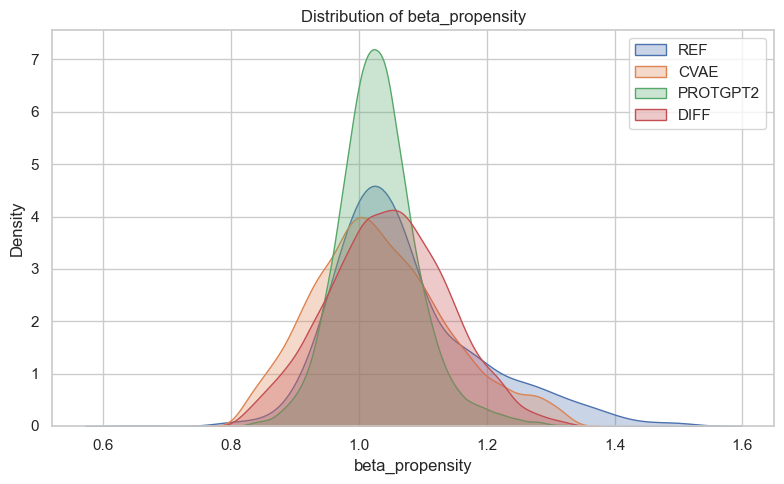

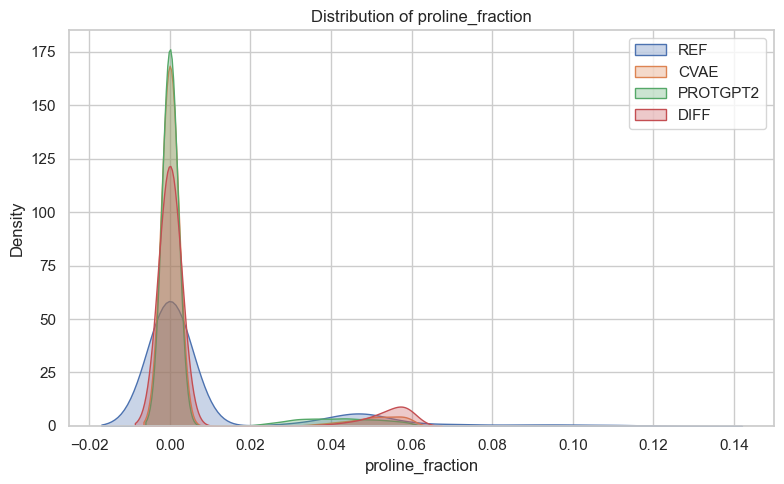

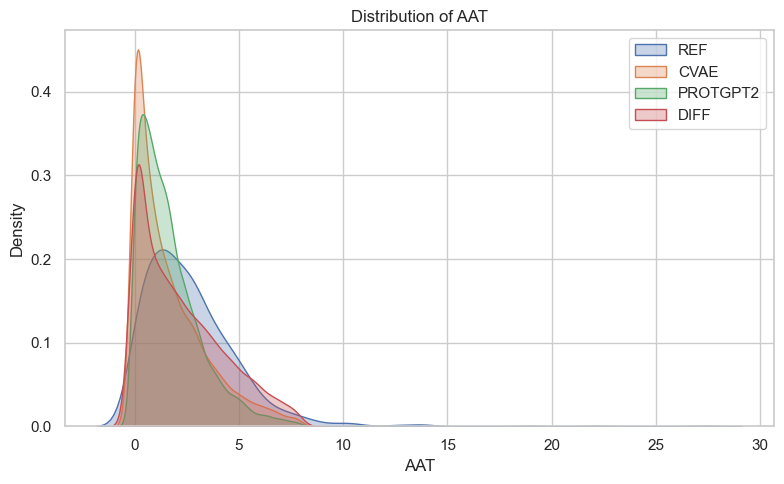

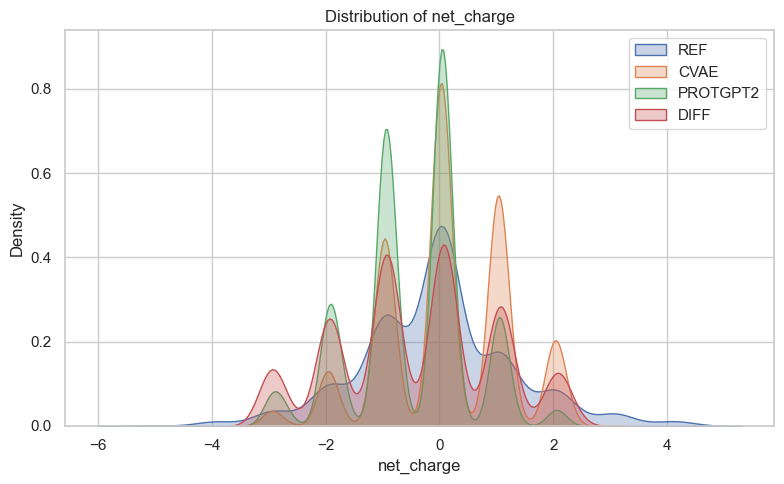

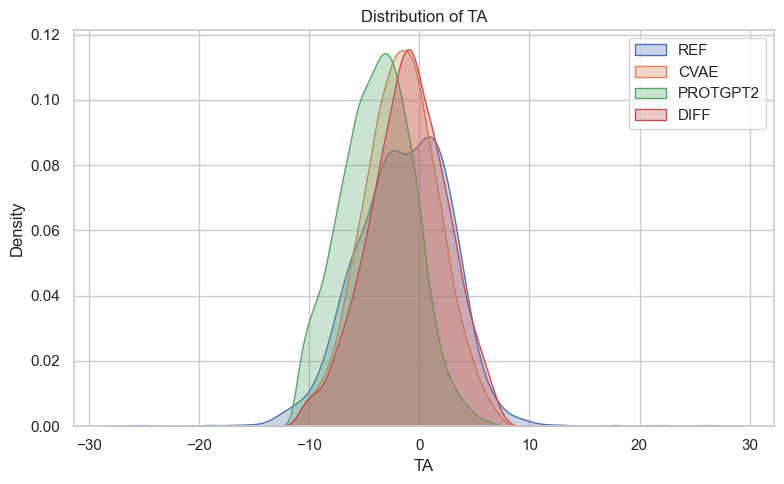

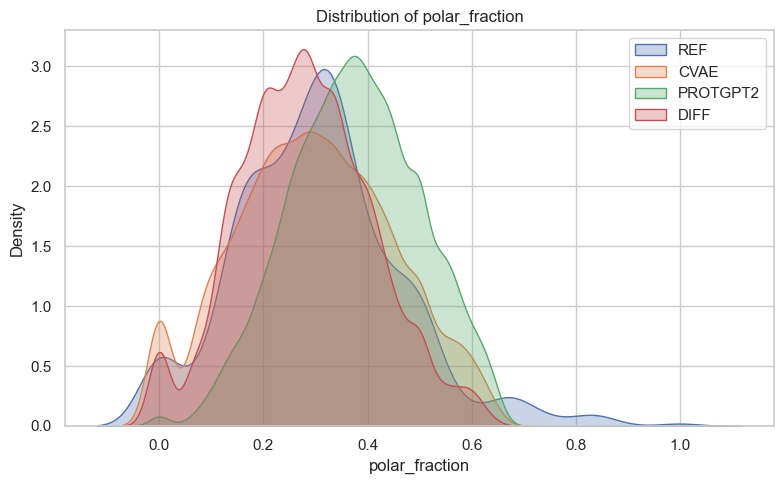

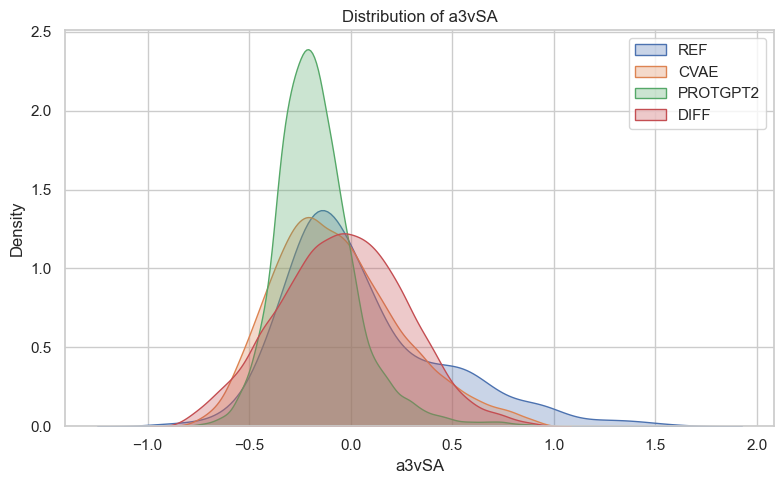

In [207]:
plot_feature_distributions()

In [208]:
def plot_boxplots():
    for feat in feature_cols:
        plt.figure(figsize=(8,5))

        data = []
        labels = []

        for name, df in datasets.items():
            data.extend(df[feat].values)
            labels.extend([name]*len(df))

        temp = pd.DataFrame({"value": data, "group": labels})

        sns.boxplot(x="group", y="value", data=temp, palette=palette)

        plt.title(f"Boxplot: {feat}")
        plt.tight_layout()
        #plt.savefig(f"figures/box_{feat}.png", dpi=300)
        #plt.close()
        plt.show()

C:\Users\marts\AppData\Local\Temp\ipykernel_32408\1093691133.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y="value", data=temp, palette=palette)


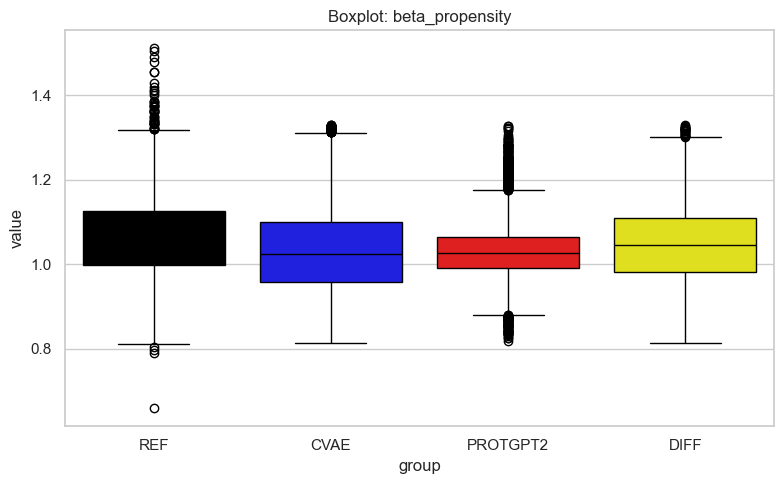

C:\Users\marts\AppData\Local\Temp\ipykernel_32408\1093691133.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y="value", data=temp, palette=palette)


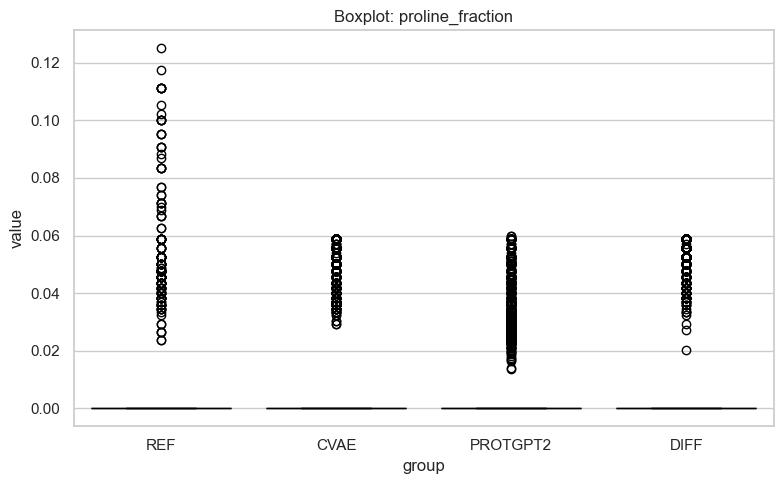

C:\Users\marts\AppData\Local\Temp\ipykernel_32408\1093691133.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y="value", data=temp, palette=palette)


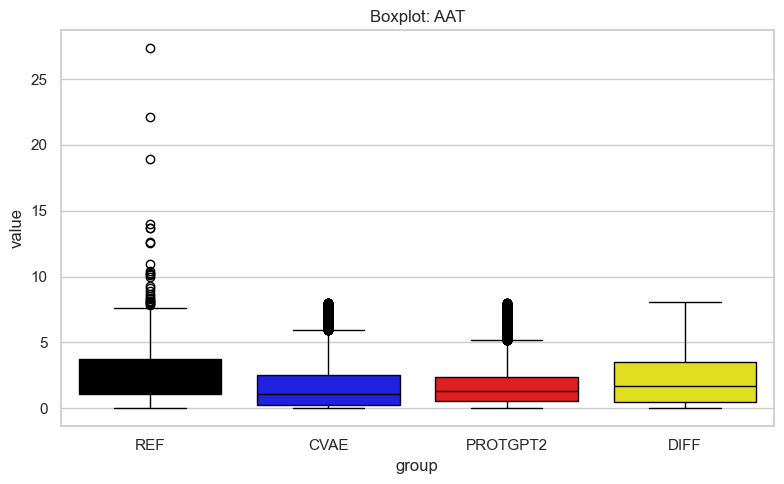

C:\Users\marts\AppData\Local\Temp\ipykernel_32408\1093691133.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y="value", data=temp, palette=palette)


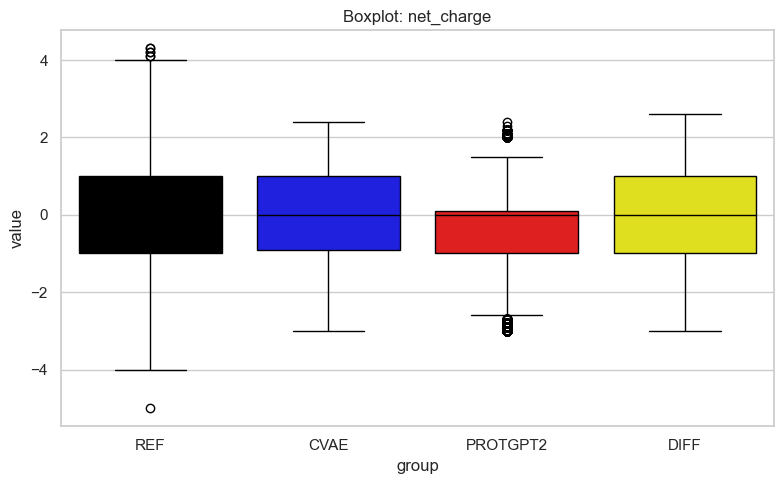

C:\Users\marts\AppData\Local\Temp\ipykernel_32408\1093691133.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y="value", data=temp, palette=palette)


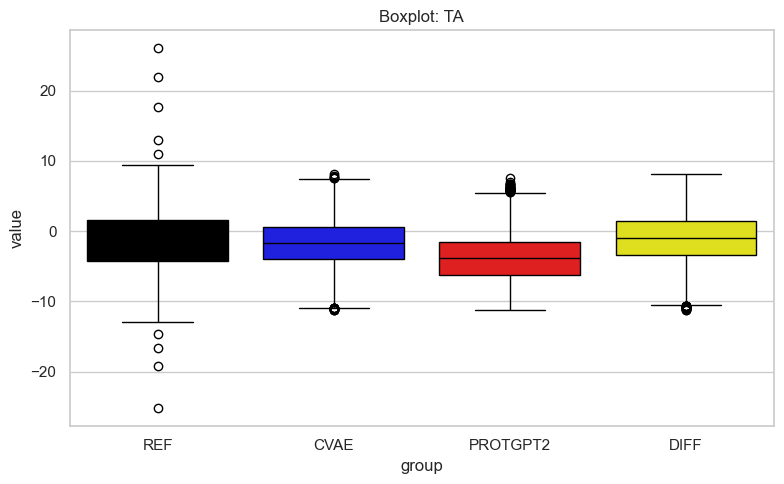

C:\Users\marts\AppData\Local\Temp\ipykernel_32408\1093691133.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y="value", data=temp, palette=palette)


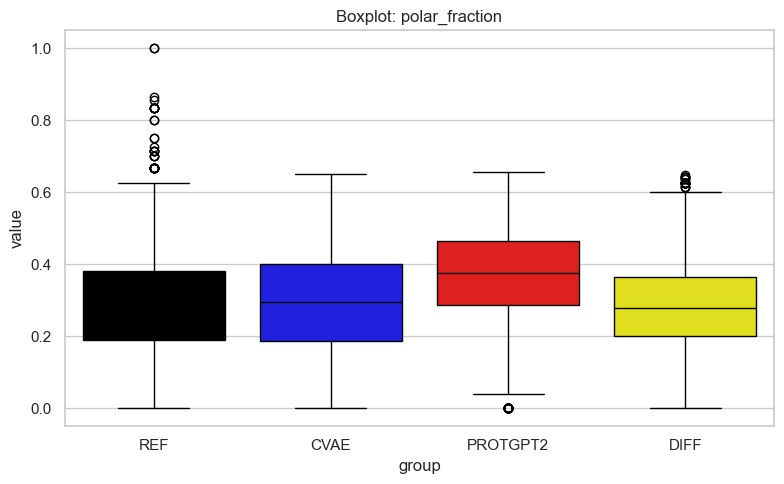

C:\Users\marts\AppData\Local\Temp\ipykernel_32408\1093691133.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y="value", data=temp, palette=palette)


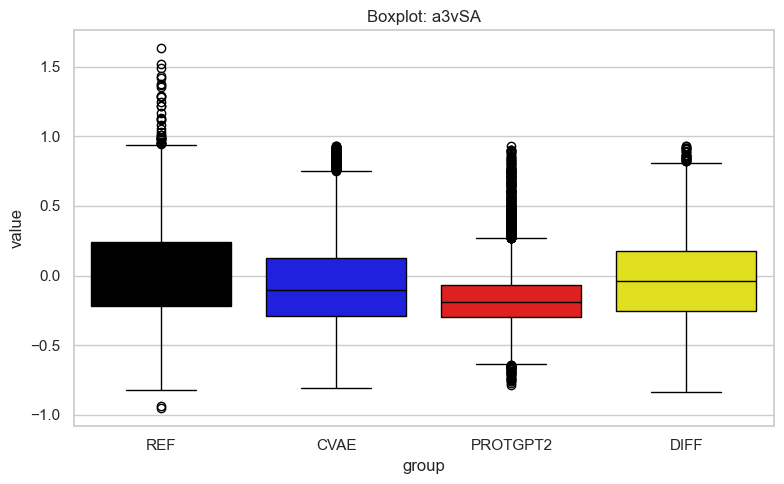

In [209]:
plot_boxplots()

In [210]:
def interpret_pvalue(p):
    if p < 0.001:
        return "very strong difference"
    elif p < 0.01:
        return "strong difference"
    elif p < 0.05:
        return "significant difference"
    else:
        return "lack of difference"


def statistical_tests():
    results = []

    ref = df_ref

    for name, df in datasets.items():
        if name == "REF":
            continue

        for feat in feature_cols:
            ks = ks_2samp(ref[feat], df[feat])
            mw = mannwhitneyu(
                ref[feat],
                df[feat],
                alternative="two-sided"
            )

            ks_interpretation = interpret_pvalue(ks.pvalue)
            mw_interpretation = interpret_pvalue(mw.pvalue)

            conclusion = (
                f"KS: {ks_interpretation}; "
                f"MW: {mw_interpretation}"
            )

            results.append({
                "Feature": feat,
                "Comparison": f"REF vs {name}",

                "KS_stat": round(ks.statistic, 4),
                "KS_p": ks.pvalue,

                "MW_stat": round(mw.statistic, 4),
                "MW_p": mw.pvalue,

                "Conclusion": conclusion
            })

    results_df = pd.DataFrame(results)

    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 200)
    pd.set_option("display.max_colwidth", 100)

    # results_df.to_csv("figures/statistical_tests.csv", index=False)

    return results_df

In [211]:
stat_tests = statistical_tests()
stat_tests

,Feature,Comparison,KS_stat,KS_p,MW_stat,MW_p,Conclusion
0,beta_propensity,REF vs CVAE,0.1452,2.125440e-17,6469564.0,2.852373e-20,KS: very strong difference; MW: very strong difference
1,proline_fraction,REF vs CVAE,0.0896,6.879662e-07,5987196.5,8.476049e-21,KS: very strong difference; MW: very strong difference
2,AAT,REF vs CVAE,0.2602,1.649893e-55,7279237.5,1.173722e-64,KS: very strong difference; MW: very strong difference
3,net_charge,REF vs CVAE,0.0973,4.878321e-08,5021947.0,3.081563e-06,KS: very strong difference; MW: very strong difference
4,TA,REF vs CVAE,0.1081,7.803949e-10,5821024.5,2.447498e-03,KS: very strong difference; MW: strong difference
5,polar_fraction,REF vs CVAE,0.0653,7.374880e-04,5530909.5,7.957897e-01,KS: very strong difference; MW: lack of difference
6,a3vSA,REF vs CVAE,0.1127,1.203260e-10,6329163.5,3.187985e-15,KS: very strong difference; MW: very strong difference
7,beta_propensity,REF vs PROTGPT2,0.1903,5.405888e-30,7477533.0,1.089073e-22,KS: very strong difference; MW: very strong difference
8,proline_fraction,REF vs PROTGPT2,0.0842,3.447706e-06,6746161.5,2.310902e-11,KS: very strong difference; MW: very strong difference
9,AAT,REF vs PROTGPT2,0.2366,2.489877e-46,8147825.5,1.175735e-53,KS: very strong difference; MW: very strong difference


In [212]:
def summarize_distribution_tests(results_df, alpha=0.05):
    print("=" * 80)
    print("DISTRIBUTION COMPARISON SUMMARY")
    print("=" * 80)

    comparisons = results_df["Comparison"].unique()

    for comp in comparisons:

        print(f"\n### {comp}")
        print("-" * 80)

        sub = results_df[
            results_df["Comparison"] == comp
        ].copy()

        sub = sub.sort_values("KS_stat", ascending=True)

        for _, row in sub.iterrows():

            feature = row["Feature"]
            ks = row["KS_stat"]
            ks_p = row["KS_p"]
            mw_p = row["MW_p"]

            # interpretacja KS
            if ks < 0.10:
                similarity = "VERY SIMILAR"
            elif ks < 0.20:
                similarity = "MODERATELY SIMILAR"
            elif ks < 0.35:
                similarity = "DIFFERENT"
            else:
                similarity = "VERY DIFFERENT"

            # significance
            sig = (
                "SIGNIFICANT"
                if (ks_p < alpha and mw_p < alpha)
                else "NOT SIGNIFICANT"
            )

            print(
                f"{feature:<20}"
                f" KS={ks:.3f} | "
                f"{similarity:<20} | "
                f"{sig}"
            )

        # najbardziej podobne
        best = sub.iloc[0]

        # najbardziej różne
        worst = sub.iloc[-1]

        print("\nMost similar to reference:")
        print(
            f"  {best['Feature']} "
            f"(KS={best['KS_stat']:.3f})"
        )

        print("\nMost different from reference:")
        print(
            f"  {worst['Feature']} "
            f"(KS={worst['KS_stat']:.3f})"
        )

    print("\n" + "=" * 80)

    # global comparison
    print("\n### GLOBAL MODEL COMPARISON")
    print("-" * 80)

    model_scores = (
        results_df
        .groupby("Comparison")["KS_stat"]
        .mean()
        .sort_values()
    )

    for comp, score in model_scores.items():
        print(f"{comp:<20} mean KS = {score:.3f}")

    best_model = model_scores.index[0]

    print(f"\nClosest overall to reference: {best_model}")

    print("=" * 80)

In [213]:
summarize_distribution_tests(stat_tests)

DISTRIBUTION COMPARISON SUMMARY

### REF vs CVAE
--------------------------------------------------------------------------------
polar_fraction       KS=0.065 | VERY SIMILAR         | NOT SIGNIFICANT
proline_fraction     KS=0.090 | VERY SIMILAR         | SIGNIFICANT
net_charge           KS=0.097 | VERY SIMILAR         | SIGNIFICANT
TA                   KS=0.108 | MODERATELY SIMILAR   | SIGNIFICANT
a3vSA                KS=0.113 | MODERATELY SIMILAR   | SIGNIFICANT
beta_propensity      KS=0.145 | MODERATELY SIMILAR   | SIGNIFICANT
AAT                  KS=0.260 | DIFFERENT            | SIGNIFICANT

Most similar to reference:
  polar_fraction (KS=0.065)

Most different from reference:
  AAT (KS=0.260)

### REF vs PROTGPT2
--------------------------------------------------------------------------------
proline_fraction     KS=0.084 | VERY SIMILAR         | SIGNIFICANT
net_charge           KS=0.142 | MODERATELY SIMILAR   | SIGNIFICANT
beta_propensity      KS=0.190 | MODERATELY SIMILAR   | S

In [214]:
def plot_pca_tsne(dfs_dict, feature_cols, color_col=None, perplexity=30, random_state=42, figsize=(14, 6)):
    prepared = []

    for label, df in dfs_dict.items():
        df_ = df.copy()

        df_ = df_[feature_cols]

        df_ = df_.groupby(level=0, axis=1).mean()

        df_["source"] = label

        if color_col and color_col in df.columns:
            df_[color_col] = df[color_col].values

        prepared.append(df_)

    df_all = pd.concat(prepared, ignore_index=True)

    df_all = df_all.dropna(subset=feature_cols)

    X = df_all[feature_cols].values
    y = df_all["source"].values

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    # tSNE
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_state)
    X_tsne = tsne.fit_transform(X_scaled)

    # plot
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # PCA
    for label in np.unique(y):
        idx = y == label
        axes[0].scatter(
            X_pca[idx, 0],
            X_pca[idx, 1],
            label=label,
            alpha=0.6
        )

    axes[0].set_title("PCA")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[0].legend()

    # t-SEN
    for label in np.unique(y):
        idx = y == label
        axes[1].scatter(
            X_tsne[idx, 0],
            X_tsne[idx, 1],
            label=label,
            alpha=0.6
        )

    axes[1].set_title("t-SNE")
    axes[1].set_xlabel("TSNE1")
    axes[1].set_ylabel("TSNE2")
    axes[1].legend()

    plt.tight_layout()
    #plt.savefig("./files/plots/generated_vs_ref_pca_tsne.svg", format="svg", bbox_inches="tight")
    plt.show()

C:\Users\marts\AppData\Local\Temp\ipykernel_32408\2843478847.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_ = df_.groupby(level=0, axis=1).mean()
C:\Users\marts\AppData\Local\Temp\ipykernel_32408\2843478847.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_ = df_.groupby(level=0, axis=1).mean()
C:\Users\marts\AppData\Local\Temp\ipykernel_32408\2843478847.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_ = df_.groupby(level=0, axis=1).mean()
C:\Users\marts\AppData\Local\Temp\ipykernel_32408\2843478847.py:9: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  df_ = df_.groupby(level=0, axis=1).mean()


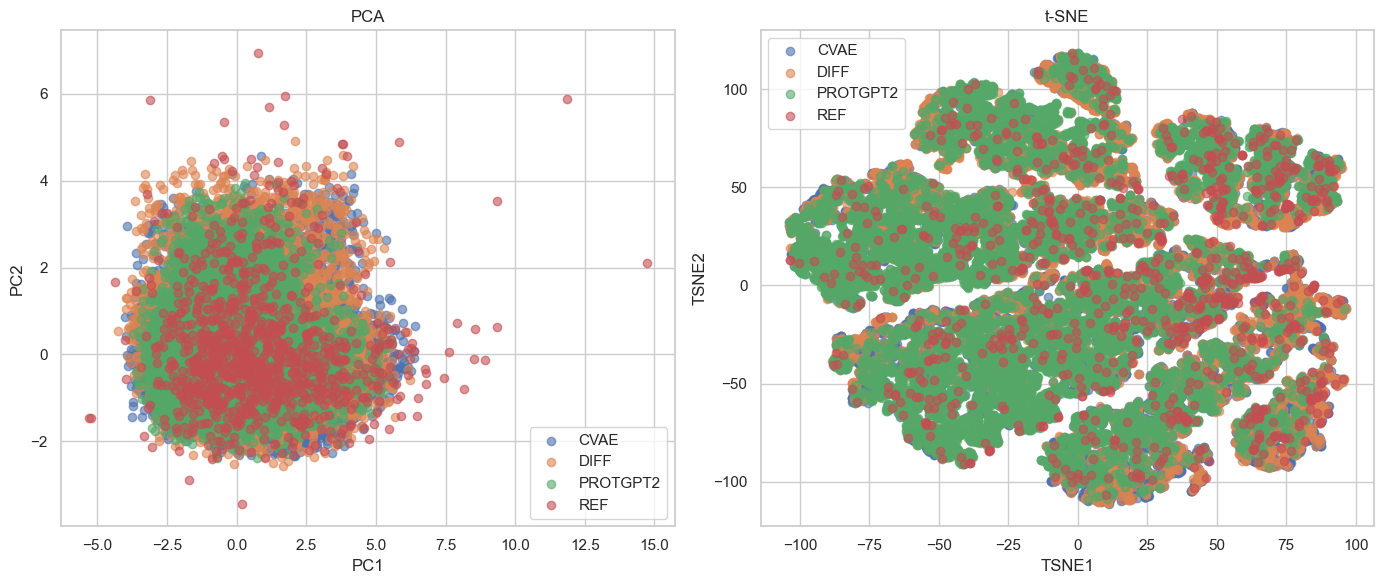

In [215]:
plot_pca_tsne(datasets, feature_cols)

<Axes: ylabel='Count'>

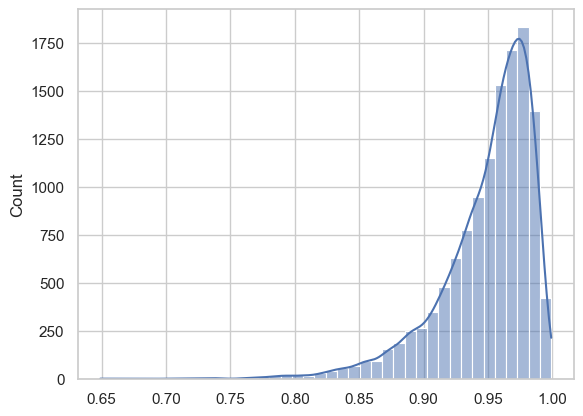

In [216]:
from sklearn.metrics.pairwise import cosine_similarity

ref = StandardScaler().fit_transform(df_ref[feature_cols])
syn = StandardScaler().fit_transform(df_protgpt_nr[feature_cols])

sim_matrix = cosine_similarity(syn, ref)

best_sim = sim_matrix.max(axis=1)

sns.histplot(best_sim, bins=40, kde=True)

<Axes: ylabel='Count'>

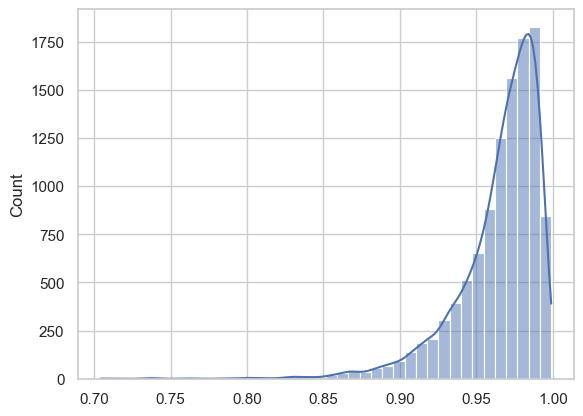

In [217]:
ref = StandardScaler().fit_transform(df_ref[feature_cols])
syn = StandardScaler().fit_transform(df_cvae_nr[feature_cols])

sim_matrix = cosine_similarity(syn, ref)

best_sim = sim_matrix.max(axis=1)

sns.histplot(best_sim, bins=40, kde=True)

<Axes: ylabel='Count'>

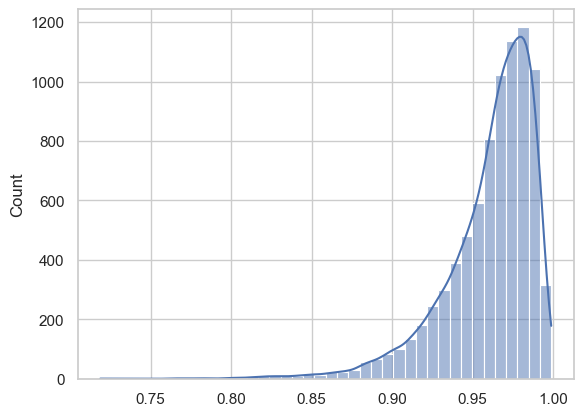

In [223]:
ref = StandardScaler().fit_transform(df_ref[feature_cols])
syn = StandardScaler().fit_transform(df_diff_nr[feature_cols])

sim_matrix = cosine_similarity(syn, ref)

best_sim = sim_matrix.max(axis=1)

sns.histplot(best_sim, bins=40, kde=True)

In [218]:
def summary_table():
    rows = []

    for name, df in datasets.items():
        for feat in feature_cols:
            rows.append({
                "dataset": name,
                "feature": feat,
                "mean": df[feat].mean(),
                "std": df[feat].std(),
                "entropy": entropy(np.histogram(df[feat], bins=20, density=True)[0] + 1e-9)
            })

    df_out = pd.DataFrame(rows)
    print(df_out)
    #df_out.to_csv("figures/summary_stats.csv", index=False)

In [219]:
summary_table()

     dataset           feature      mean       std   entropy
0        REF   beta_propensity  1.071727  0.114909  2.306264
1        REF  proline_fraction  0.009457  0.022557  0.847437
2        REF               AAT  2.691157  2.376518  1.638181
3        REF        net_charge -0.061928  1.339091  2.014038
4        REF                TA -1.394870  4.361861  1.916669
5        REF    polar_fraction  0.304622  0.158452  2.428473
6        REF             a3vSA  0.047483  0.392848  2.409483
7       CVAE   beta_propensity  1.033970  0.105386  2.786885
8       CVAE  proline_fraction  0.004119  0.013979  0.439755
9       CVAE               AAT  1.649750  1.734721  2.386366
10      CVAE        net_charge  0.106507  1.105274  1.809491
11      CVAE                TA -1.709610  3.389425  2.670931
12      CVAE    polar_fraction  0.297106  0.151112  2.863016
13      CVAE             a3vSA -0.065882  0.313586  2.666858
14  PROTGPT2   beta_propensity  1.030151  0.063056  2.294207
15  PROTGPT2  proline_fr

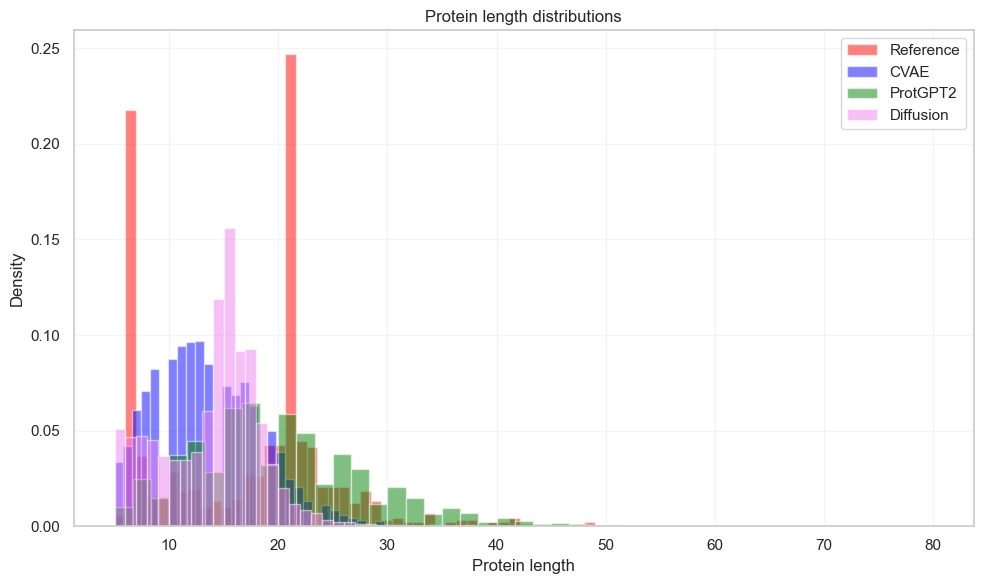

In [246]:
df_cvae_nr = df_cvae_nr.loc[:, ~df_cvae_nr.columns.duplicated()]
df_protgpt_nr = df_protgpt_nr.loc[:, ~df_protgpt_nr.columns.duplicated()]
df_diff_nr = df_diff_nr.loc[:, ~df_diff_nr.columns.duplicated()]

plt.figure(figsize=(10, 6))

bins = 45

plt.hist(
    df_ref["length"],
    bins=bins,
    alpha=0.5,
    color="red",
    label="Reference",
    density=True
)

plt.hist(
    df_cvae_nr["length"],
    bins=bins,
    alpha=0.5,
    color="blue",
    label="CVAE",
    density=True
)

plt.hist(
    df_protgpt_nr["length"],
    bins=bins,
    alpha=0.5,
    color="green",
    label="ProtGPT2",
    density=True
)

plt.hist(
    df_diff_nr["length"],
    bins=bins,
    alpha=0.5,
    color="violet",
    label="Diffusion",
    density=True
)

plt.xlabel("Protein length")
plt.ylabel("Density")
plt.title("Protein length distributions")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Final files

In [238]:
def extract_number(header):
    match = re.search(r"(\d+)", header)
    return int(match.group(1)) if match else float("inf")

In [239]:
df_cvae_nr = df_cvae_nr.sort_values(
    by="id",
    key=lambda col: col.map(extract_number)
)

df_cvae_nr.to_csv(
    "./files/final_datasets/cvae_final.csv",
    index=False
)
write_fasta(df_cvae_nr, "./files/final_datasets/cvae_final.fasta")

In [240]:
df_protgpt_nr = df_protgpt_nr.sort_values(
    by="id",
    key=lambda col: col.map(extract_number)
)

df_protgpt_nr.to_csv(
    "./files/final_datasets/protgpt_final.csv",
    index=False
)
write_fasta(df_protgpt_nr, "./files/final_datasets/protgpt_final.fasta")

In [237]:
df_diff_nr = df_diff_nr.sort_values(
    by="id",
    key=lambda col: col.map(extract_number)
)
df_diff_nr.to_csv(
    "./files/final_datasets/diff_final.csv",
    index=False
)
write_fasta(df_diff_nr, "./files/final_datasets/diff_final.fasta")

## Data to alphafold

In [248]:
files = [
    "./files/final_datasets/cvae_final.fasta",
    "./files/final_datasets/diff_final.fasta",
    "./files/final_datasets/protgpt_final.fasta"
]

N_RANDOM = 1000
CHUNK_SIZE = 100

output_dir = Path("./files/final_datasets/to_alphafold")
output_dir.mkdir(parents=True, exist_ok=True)


def read_fasta(fasta_path):
    sequences = []

    with open(fasta_path, "r") as f:
        header = None
        seq_lines = []

        for line in f:
            line = line.strip()

            if not line:
                continue

            if line.startswith(">"):
                if header is not None:
                    sequences.append((header, "".join(seq_lines)))
                header = line
                seq_lines = []
            else:
                seq_lines.append(line)

        if header is not None:
            sequences.append((header, "".join(seq_lines)))

    return sequences


for filepath in files:
    seqs = read_fasta(filepath)

    selected = random.sample(seqs, min(N_RANDOM, len(seqs)))

    input_name = Path(filepath).stem

    for i in range(0, len(selected), CHUNK_SIZE):
        chunk = selected[i:i + CHUNK_SIZE]

        output_file = output_dir / f"{input_name}_part_{i // CHUNK_SIZE + 1}.fasta"

        with open(output_file, "w") as out:
            for header, seq in chunk:
                out.write(header + "\n")
                out.write(seq + "\n")

        print(f"Zapisano: {output_file} ({len(chunk)} sekwencji)")

Zapisano: files\final_datasets\to_alphafold\cvae_final_part_1.fasta (100 sekwencji)
Zapisano: files\final_datasets\to_alphafold\cvae_final_part_2.fasta (100 sekwencji)
Zapisano: files\final_datasets\to_alphafold\cvae_final_part_3.fasta (100 sekwencji)
Zapisano: files\final_datasets\to_alphafold\cvae_final_part_4.fasta (100 sekwencji)
Zapisano: files\final_datasets\to_alphafold\cvae_final_part_5.fasta (100 sekwencji)
Zapisano: files\final_datasets\to_alphafold\cvae_final_part_6.fasta (100 sekwencji)
Zapisano: files\final_datasets\to_alphafold\cvae_final_part_7.fasta (100 sekwencji)
Zapisano: files\final_datasets\to_alphafold\cvae_final_part_8.fasta (100 sekwencji)
Zapisano: files\final_datasets\to_alphafold\cvae_final_part_9.fasta (100 sekwencji)
Zapisano: files\final_datasets\to_alphafold\cvae_final_part_10.fasta (100 sekwencji)
Zapisano: files\final_datasets\to_alphafold\diff_final_part_1.fasta (100 sekwencji)
Zapisano: files\final_datasets\to_alphafold\diff_final_part_2.fasta (100 se

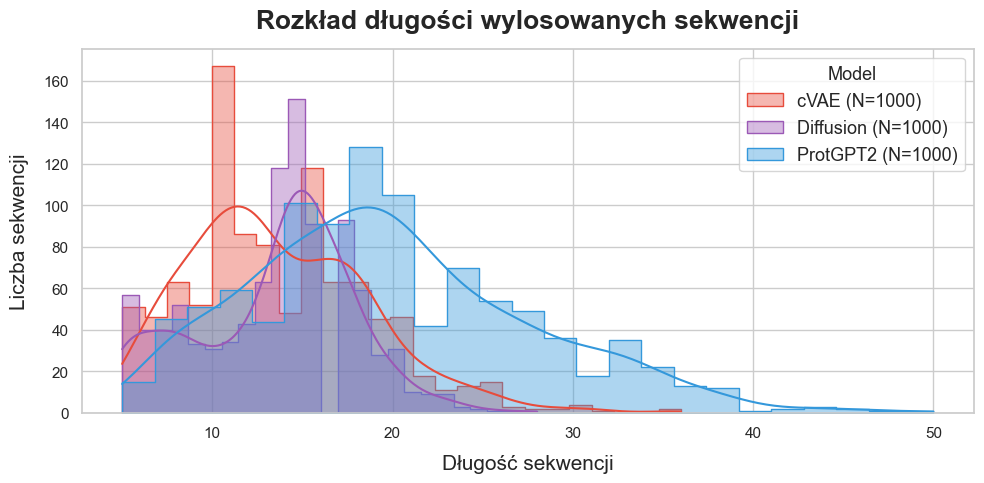

In [265]:
lengths_data = {"cVAE": [], "Diffusion": [], "ProtGPT2": []}

def get_sequence_lengths(file_path):
    lengths = []
    current_len = 0
    with open(file_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if current_len > 0:
                    lengths.append(current_len)
                    current_len = 0
            else:
                current_len += len(line)
        if current_len > 0:
            lengths.append(current_len)
    return lengths

fasta_files = glob.glob(os.path.join(output_dir, "*.fasta"))

for file_path in fasta_files:
    file_name = os.path.basename(file_path)

    if "cvae" in file_name:
        lengths_data["cVAE"].extend(get_sequence_lengths(file_path))
    elif "diff" in file_name:
        lengths_data["Diffusion"].extend(get_sequence_lengths(file_path))
    elif "protgpt" in file_name:
        lengths_data["ProtGPT2"].extend(get_sequence_lengths(file_path))

plt.figure(figsize=(10, 5))

sns.set_theme(style="whitegrid")

colors = {"cVAE": "#e74c3c", "Diffusion": "#9b59b6", "ProtGPT2": "#3498db"}

for model_name, lengths in lengths_data.items():
    sns.histplot(
            lengths,
            label=f"{model_name} (N={len(lengths)})",
            color=colors[model_name],
            alpha=0.4,
            kde=True,
            element="step",
            stat="count",
            bins=25
        )

plt.title("Rozkład długości wylosowanych sekwencji", fontsize=19, fontweight='bold', pad=15)
plt.xlabel("Długość sekwencji", fontsize=15, labelpad=10)
plt.ylabel("Liczba sekwencji", fontsize=15, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(title="Model", fontsize=13, title_fontsize=13, loc="upper right")

plt.tight_layout()
plt.savefig("./files/plots/hist_lenght_to_alphafold.svg", format="svg")
plt.show()

In [250]:
main_path = "./files/final_datasets/from_alphafold"
for model in ["protgpt", "diff", "cvae"]:

    dfs = []

    for part in range(1, 11):
        fname = f"{main_path}/plddt_summary_{model}_part{part}_100.txt"

        try:
            df = pd.read_csv(fname, sep=r"\s+", engine="python")
            dfs.append(df)
        except FileNotFoundError:
            print(f"Missing: {fname}")

    combined = pd.concat(dfs, ignore_index=True)

    outname = f"{main_path}/plddt_summary_{model}_all.csv"
    combined.to_csv(outname, index=False)

In [253]:
plddt_cvae = pd.read_csv(f"{main_path}/plddt_summary_cvae_all.csv")
plddt_protgpt = pd.read_csv(f"{main_path}/plddt_summary_protgpt_all.csv")
plddt_diff = pd.read_csv(f"{main_path}/plddt_summary_diff_all.csv")

df_cvae_nr_plddt = df_cvae_nr.merge(
    plddt_cvae[["id", "pLDDT_Rank1"]],
    on="id",
    how="inner"
)

df_protgpt_nr_plddt = df_protgpt_nr.merge(
    plddt_protgpt[["id", "pLDDT_Rank1"]],
    on="id",
    how="inner"
)

df_diff_nr_plddt = df_diff_nr.merge(
    plddt_diff[["id", "pLDDT_Rank1"]],
    on="id",
    how="inner"
)

df_cvae_nr_filtered = df_cvae_nr_plddt[df_cvae_nr_plddt["pLDDT_Rank1"] >= 70]
df_protgpt_nr_filtered = df_protgpt_nr_plddt[df_protgpt_nr_plddt["pLDDT_Rank1"] >= 70]
df_diff_nr_filtered = df_diff_nr_plddt[df_diff_nr_plddt["pLDDT_Rank1"] >= 70]

df_cvae_nr_filtered.to_csv(f"{main_path}/cvae_features_filtered.csv", index=False)
df_protgpt_nr_filtered.to_csv(f"{main_path}/protgpt_features_filtered.csv", index=False)
df_diff_nr_filtered.to_csv(f"{main_path}/diff_features_filtered.csv", index=False)

for name, df in [
    ("cvae", df_cvae_nr_filtered),
    ("protgpt", df_protgpt_nr_filtered),
    ("diff", df_diff_nr_filtered),
]:
    print(f"{name}: {len(df)} sekwencji po filtrze pLDDT >= 70")

cvae: 841 sekwencji po filtrze pLDDT >= 70
protgpt: 579 sekwencji po filtrze pLDDT >= 70
diff: 655 sekwencji po filtrze pLDDT >= 70


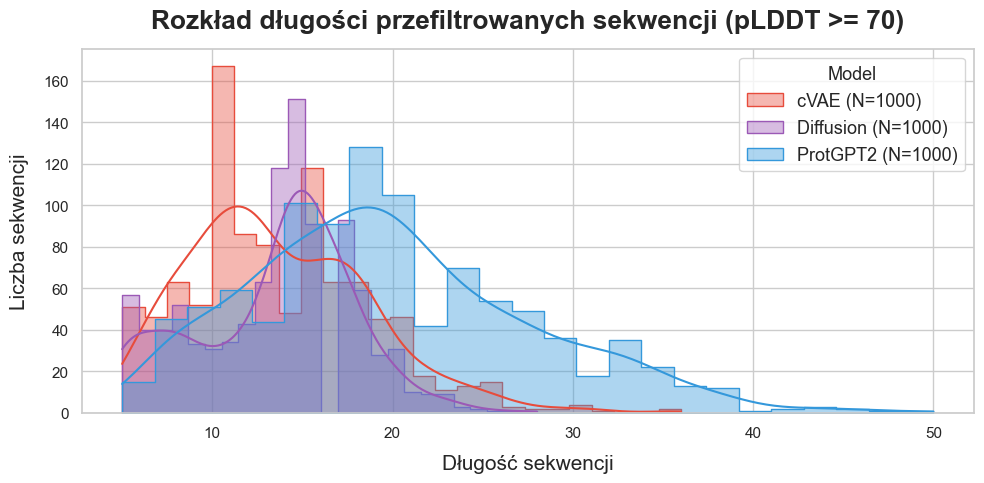

In [266]:
lengths_data_after = {
    "cVAE": df_cvae_nr_filtered['length'].tolist(),
    "Diffusion": df_diff_nr_filtered['length'].tolist(),
    "ProtGPT2": df_protgpt_nr_filtered['length'].tolist()
}
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

for model_name, lengths in lengths_data.items():
    sns.histplot(
        lengths,
        label=f"{model_name} (N={len(lengths)})",
        color=colors[model_name],
        alpha=0.4,
        kde=True,
        element="step",
        stat="count",
        bins=25
    )

plt.title("Rozkład długości przefiltrowanych sekwencji (pLDDT >= 70)", fontsize=19, fontweight='bold', pad=15)
plt.xlabel("Długość sekwencji", fontsize=15, labelpad=10)
plt.ylabel("Liczba sekwencji", fontsize=15, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.legend(title="Model", fontsize=13, title_fontsize=13, loc="upper right")

output_plot_path = "./files/plots/hist_length_filtered_alphafold.svg"
os.makedirs(os.path.dirname(output_plot_path), exist_ok=True)

plt.tight_layout()
plt.savefig(output_plot_path, format="svg")
plt.show()

In [272]:
from scipy import stats
import numpy as np
import pandas as pd


stat_results = []

print("="*80)
print("ANALIZA STATYSTYCZNA: PORÓWNANIE ROZKŁADÓW DŁUGOŚCI (PRZED VS PO FILTRACJI)")
print("="*80)

for model in ["cVAE", "Diffusion", "ProtGPT2"]:
    bef = lengths_data[model]
    aft = lengths_data_after[model]

    mean_b, median_b = np.mean(bef), np.median(bef)
    mean_a, median_a = np.mean(aft), np.median(aft)
    std_b, std_a = np.std(bef), np.std(aft)

    ks_stat, p_ks = stats.ks_2samp(bef, aft)

    mw_stat, p_mw = stats.mannwhitneyu(bef, aft, alternative='two-sided')

    p_ks_str = "< 0.0001" if p_ks < 0.0001 else f"{p_ks:.4f}"
    p_mw_str = "< 0.0001" if p_mw < 0.0001 else f"{p_mw:.4f}"

    stat_results.append({
        "Model": model,
        "N Przed": len(bef),
        "Mediana Przed": median_b,
        "Średnia Przed (±SD)": f"{mean_b:.1f} (±{std_b:.1f})",
        "N Po": len(aft),
        "Mediana Po": median_a,
        "Średnia Po (±SD)": f"{mean_a:.1f} (±{std_a:.1f})",
        "Test K-S (p-value)": p_ks_str,
        "Test Manna-Wh. (p-value)": p_mw_str,
        "Istotna zmiana?": "TAK (p < 0.05)" if p_ks < 0.05 else "NIE"
    })

df_stats_summary = pd.DataFrame(stat_results)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
display(df_stats_summary)

df_stats_summary.to_csv(f"./files/lenghts_alpha_fold_stats.csv", index=False)

ANALIZA STATYSTYCZNA: PORÓWNANIE ROZKŁADÓW DŁUGOŚCI (PRZED VS PO FILTRACJI)


,Model,N Przed,Mediana Przed,Średnia Przed (±SD),N Po,Mediana Po,Średnia Po (±SD),Test K-S (p-value),Test Manna-Wh. (p-value),Istotna zmiana?
0,cVAE,1000,13.0,13.7 (±5.1),841,13.0,13.4 (±4.8),0.9759,0.3555,NIE
1,Diffusion,1000,14.0,13.5 (±4.4),655,14.0,13.0 (±4.4),0.2473,0.0352,NIE
2,ProtGPT2,1000,19.0,19.8 (±7.8),579,16.0,16.6 (±6.3),< 0.0001,< 0.0001,TAK (p < 0.05)


In [273]:
chunk_size = 130

for i, chunk in enumerate(np.array_split(df_ref, np.ceil(len(df_ref) / chunk_size))):
    file_name = f"./files/final_datasets/to_alphafold/ref_amy_part{i+1}.fasta"

    with open(file_name, "w") as f:
        for _, row in chunk.iterrows():
            f.write(f">{row['id']}\n{row['sequence']}\n")

    print(f"Zapisano {len(chunk)} sekwencji do {file_name}")

C:\Users\marts\anaconda3\envs\protein310\lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Zapisano 126 sekwencji do ./files/final_datasets/to_alphafold/ref_amy_part1.fasta
Zapisano 126 sekwencji do ./files/final_datasets/to_alphafold/ref_amy_part2.fasta
Zapisano 126 sekwencji do ./files/final_datasets/to_alphafold/ref_amy_part3.fasta
Zapisano 126 sekwencji do ./files/final_datasets/to_alphafold/ref_amy_part4.fasta
Zapisano 126 sekwencji do ./files/final_datasets/to_alphafold/ref_amy_part5.fasta
Zapisano 126 sekwencji do ./files/final_datasets/to_alphafold/ref_amy_part6.fasta
Zapisano 125 sekwencji do ./files/final_datasets/to_alphafold/ref_amy_part7.fasta
Zapisano 125 sekwencji do ./files/final_datasets/to_alphafold/ref_amy_part8.fasta
